# Mini Project: Predicting Student Dropout with Supervised Learning



# Stage 1 data

In [ ]:
# File URL
import os
from dotenv import load_dotenv
load_dotenv()
file_url = os.getenv('FILE_URL')

**Stage 1: Pre-processing instructions**
- Remove any columns not useful in the analysis (LearnerCode).
- Remove columns with categorical features with high cardinality (use >200 unique values, as a guideline for this data set).
- Remove columns with > 50% data missing.
- Perform ordinal encoding for ordinal data.
- Perform one-hot encoding for all other categorical data.

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, roc_auc_score, roc_curve, precision_recall_curve, auc as sk_auc
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
# Install keras-tuner (does not come with the standard colab environment)
%pip install keras-tuner -q
import keras_tuner as kt
from tensorflow import keras
import random
from sklearn.impute import SimpleImputer


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 2.0 MB/s eta 0:00:00a 0:00:01


In [ ]:
# Load dataset
df_stage1 = pd.read_csv(file_url)

# Check data has loaded 
df_stage1.head(5)

## Exploratory Data Analysis (EDA)

In [ ]:
# Basic data exploration. Check shape and missing vals
print(f"Number of observations: {df_stage1.shape[0]}")
print(f"Number of features: {df_stage1.shape[1]}")
print(f"Number of duplicates: {df_stage1.duplicated().sum()}")

print("\n--- Data types ---")
display(df_stage1.info())

print("\n--- Missing Values ---")
display(df_stage1.isnull().sum()[df_stage1.isnull().sum() > 0])



 **Summary:**

The dataset contains a moderate number of features and observations, with no duplicate records identified.

It includes a mix of numerical, boolean, and categorical variables.

Two variables with substantial missingness were removed during preprocessing.

## Data Pre-processing


In [ ]:
df_stage1 = df_stage1.copy()

# Drop identifier column
if 'record_id' in df_stage1.columns:
    df_stage1.drop(columns=['record_id'], inplace=True)

In [ ]:
# Remove features with more than 50% missing data
missing_percent = df_stage1.isnull().mean()
cols_to_drop_missing = missing_percent[missing_percent > 0.5].index.tolist()
print(f"Dropping columns with >50% missing data: {cols_to_drop_missing}")
df_stage1.drop(columns=cols_to_drop_missing, inplace=True)

print(f"Shape after dropping high-missing columns: {df_stage1.shape}")

### Feature Engineering

In [ ]:
# Convert date of birth to Age before checking for high cardinality
df_stage1['DateofBirth'] = pd.to_datetime(df_stage1['DateofBirth'], dayfirst=True, errors='coerce')
df_stage1['Age'] = pd.Timestamp.now().year - df_stage1['DateofBirth'].dt.year
df_stage1.drop(columns=['DateofBirth'], inplace=True)

df_stage1.head(5)

In [ ]:
# Remove categorical features with high cardinality (200+)
categorical_features = df_stage1.select_dtypes(include=['object']).columns
cardinality = df_stage1[categorical_features].nunique()
display(cardinality)
cols_to_drop_cardinality = cardinality[cardinality > 200].index.tolist()
print(f"Dropping categorical columns with >200 unique values: {cols_to_drop_cardinality}")

In [ ]:
df_stage1.drop(columns=cols_to_drop_cardinality, inplace=True)
df_stage1.shape

#### EDA on features after feature engineering

In [ ]:
# Descriptive stats
display(df_stage1.describe(include=['object', 'category']))
# Numerical
df_stage1.describe().round(0)

##### Visualisations and further EDA

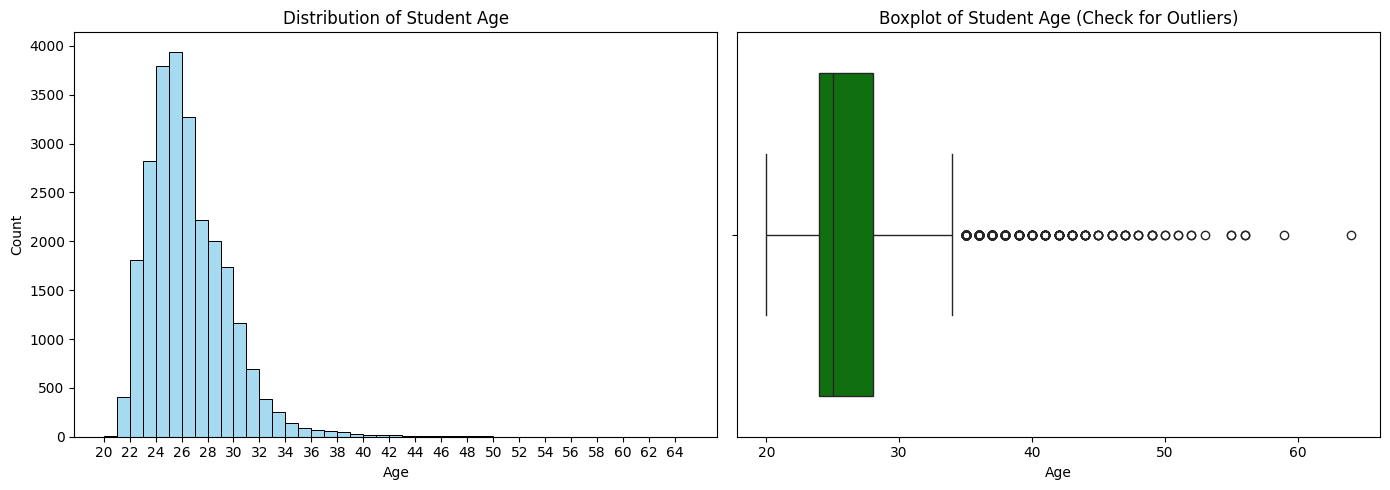

In [10]:
# AGE
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
age_data = df_stage1['Age'].dropna()
bins = range(int(age_data.min()), int(age_data.max()) + 2)

sns.histplot(age_data, bins=bins, kde=False, ax=ax[0], color='skyblue')
ax[0].set_title('Distribution of Student Age')
ax[0].set_xlabel('Age')
ax[0].set_ylabel('Count')
ax[0].set_xticks(range(int(age_data.min()), int(age_data.max()) + 1, 2))
# Boxplot
sns.boxplot(x=df_stage1['Age'], ax=ax[1], color='green')
ax[1].set_title('Boxplot of Student Age (Check for Outliers)')

plt.tight_layout()
plt.show()

**Summary of EDA visualisations**

Exploratory analysis highlighted variation in the target outcome across demographic and programme-related features.

Several variables showed potentially useful signal for distinguishing between completion and non-completion outcomes, supporting their inclusion in subsequent preprocessing and modelling stages.

#### Binary encoding - Target variable

In [ ]:
# Convert target variable (CompletedCourse) to binary encoding
print(f"CompletedCourse Values: {df_stage1['CompletedCourse'].unique()}")
target_val_counts = df_stage1['CompletedCourse'].value_counts(dropna=False)
print(f"\nTarget Variable ('CompletedCourse') value counts before encoding:\n{target_val_counts}")
df_stage1['CompletedCourse'] = df_stage1['CompletedCourse'].map({'Yes': 1, 'No': 0})

df_stage1.head(5)

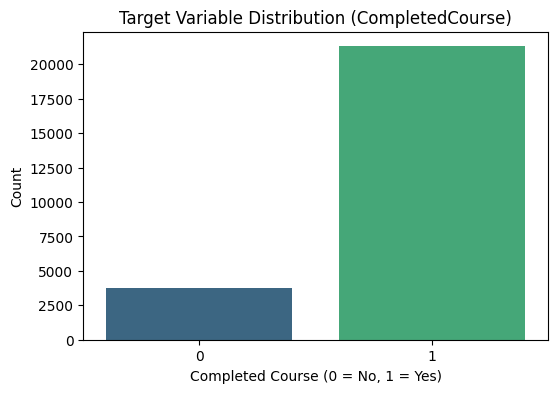

In [12]:
# Check for imbalance
plt.figure(figsize=(6, 4))
sns.countplot(
    data=df_stage1, 
    x='CompletedCourse', 
    hue='CompletedCourse',  
    palette='viridis', 
    legend=False            
)
plt.title('Target Variable Distribution (CompletedCourse)')
plt.xlabel('Completed Course (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()


This means that ~85% of the students completed their course, and only ~15% dropped out. The dataset is highly imbalanced in favour of completing the course.

### Split Training and Test Data

In [ ]:
# Separate features (X) and target variable (y)
X = df_stage1.drop('CompletedCourse', axis=1)
y = df_stage1['CompletedCourse']
# Split into 80% Training and 20% Test
X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
# Split the remaining 80% Training into 90% final training and 10% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp, y_train_temp, test_size=0.10, random_state=42, stratify=y_train_temp
)
# Verify Shapes - sanity check
print(f"Total dataset shape: {df_stage1.shape}")
print(f"Training set Features: {X_train.shape}, Target: {y_train.shape}")
print(f"Validation set Features: {X_val.shape}, Target: {y_val.shape}")
print(f"Test set Features: {X_test.shape}, Target: {y_test.shape}")

#### Ordinal Encoding

In [ ]:
# Ordinal encoding for ordinal features
# Check CourseLevel unique values as this lends itself to ordinal encoding
print(f"Course level unique vals: {df_stage1['CourseLevel'].unique()}")
# Check course level total count
print(f"Course level total count: \n{df_stage1['CourseLevel'].value_counts()}")


In [ ]:
ordinal_cols = ['ordered_category']
category_order = ['Level 1', 'Level 2', 'Level 3', 'Level 4']

ordinal_encoder = OrdinalEncoder(
    categories=[category_order],
    handle_unknown='use_encoded_value',
    unknown_value=-1,
    dtype=int
)

X_train[ordinal_cols] = ordinal_encoder.fit_transform(X_train[ordinal_cols])
X_val[ordinal_cols] = ordinal_encoder.transform(X_val[ordinal_cols])
X_test[ordinal_cols] = ordinal_encoder.transform(X_test[ordinal_cols])


#### One-hot encoding

In [ ]:
nominal_cols = X_train.select_dtypes(include=['object']).columns.tolist()
print(f"Nominal columns for one-hot encoding: {nominal_cols}")

X_train = pd.get_dummies(X_train, columns=nominal_cols, drop_first=True)
X_val = pd.get_dummies(X_val, columns=nominal_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=nominal_cols, drop_first=True)

# Align validation and test to training columns.
# validation and test sets were reindexed to match 
# the training feature columns, with missing dummy variables filled with zero
# -> consistent input dimensions
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"Training set shape after encoding:   {X_train.shape}")
print(f"Validation set shape after encoding: {X_val.shape}")
print(f"Test set shape after encoding:       {X_test.shape}")

In [ ]:
df_stage1.head()

## XGBoost baseline model

In [14]:
# ---------------------------------------------------------------------------- #
#                   Function to train XGBoost baseline model                   #
# ---------------------------------------------------------------------------- #
def train_xgb_baseline(X_train, y_train, X_val, y_val, X_test, y_test,
                       random_state=42, early_stopping_rounds=10,
                       model_name="XGBoost Baseline"):
    """
    Train and evaluate a baseline XGBoost classifier.
    """
    model = xgb.XGBClassifier(
        eval_metric='logloss',
        random_state=random_state,
        early_stopping_rounds=early_stopping_rounds
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=False
    )

    results = evaluate_xgb_model(
        model=model,
        X_test=X_test,
        y_test=y_test,
        model_name=model_name
    )

    return results


def evaluate_xgb_model(model, X_test, y_test, model_name="XGBoost"):
    """
    Generate predictions and compute evaluation metrics for a fitted XGBoost model.

    Returns:
        dict: model, predictions, probabilities, metrics, confusion matrix
    """
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_pred_proba)
    conf_matrix = confusion_matrix(y_test, y_pred)

    print(f"{model_name} Performance Metrics:")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"AUC:       {auc:.4f}")

    return {
        "model": model,
        "y_pred": y_pred,
        "y_pred_proba": y_pred_proba,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "auc": auc,
        "conf_matrix": conf_matrix
    }

In [15]:
# Instantiate baseline XGBoost model
xgb_stage1_baseline = train_xgb_baseline(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    model_name="Stage 1 XGBoost Baseline"
)

Stage 1 XGBoost Baseline Performance Metrics:
Accuracy:  0.8960
Precision: 0.9180
Recall:    0.9639
AUC:       0.8812


### Feature importance

In [16]:
# ---------------------------------------------------------------------------- #
#                      Function to plot feature importance                     #
# ---------------------------------------------------------------------------- #
def plot_xgb_feature_importance(model, X_train, stage_label="Stage", top_n=15):
    """
    Plot top N feature importances for a fitted XGBoost model.

    Parameters:
        model: fitted XGBoost model
        X_train (pd.DataFrame): training feature set used to fit the model
        stage_label (str): label to use in the plot title
        top_n (int): number of top features to display

    Returns:
        pd.DataFrame: sorted feature importance dataframe
    """
    importances = model.feature_importances_

    importance_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': importances
    })

    importance_df = importance_df.sort_values(
        by='Importance',
        ascending=False
    ).head(top_n)

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=importance_df,
        x='Importance',
        y='Feature',
        hue='Feature',
        palette='viridis',
        legend=False
    )
    plt.title(f'Top {top_n} Feature Importances ({stage_label} XGBoost)')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

    return importance_df

In [ ]:
importance_df_stage1 = plot_xgb_feature_importance(
    model=xgb_stage1_baseline["model"],
    X_train=X_train,
    stage_label="Stage 1: Baseline"
)

**Feature Importance Summary**

The model placed substantial weight on one demographic category, with several encoded subgroup features contributing more strongly than most other variables.

This pattern was broadly consistent with trends observed earlier during exploratory analysis, where completion outcomes differed across some categorical groups.

### ROC and Precision-Recall plots

In [50]:
# ---------------------------------------------------------------------------- #
#                       Function to plot ROC and PR plots                      #
# ---------------------------------------------------------------------------- #
def plot_single_model_roc_pr(y_true, y_pred_proba, title_prefix="Model"):
    """
    Plot ROC and Precision-Recall curves for a single model.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # ROC curve
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc_val = sk_auc(fpr, tpr)

    axes[0].plot(fpr, tpr, lw=2, label=f'ROC curve (AUC = {roc_auc_val:.4f})')
    axes[0].plot([0, 1], [0, 1], lw=1, linestyle='--')
    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title(f'{title_prefix} ROC Curve')
    axes[0].legend(loc="lower right")

    # PR curve
    precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_pred_proba)
    pr_auc_val = sk_auc(recall_vals, precision_vals)

    axes[1].plot(recall_vals, precision_vals, lw=2, label=f'PR curve (AUC = {pr_auc_val:.4f})')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('Recall (Sensitivity)')
    axes[1].set_ylabel('Precision')
    axes[1].set_title(f'{title_prefix} Precision-Recall Curve')
    axes[1].legend(loc="lower left")

    plt.tight_layout()
    plt.show()

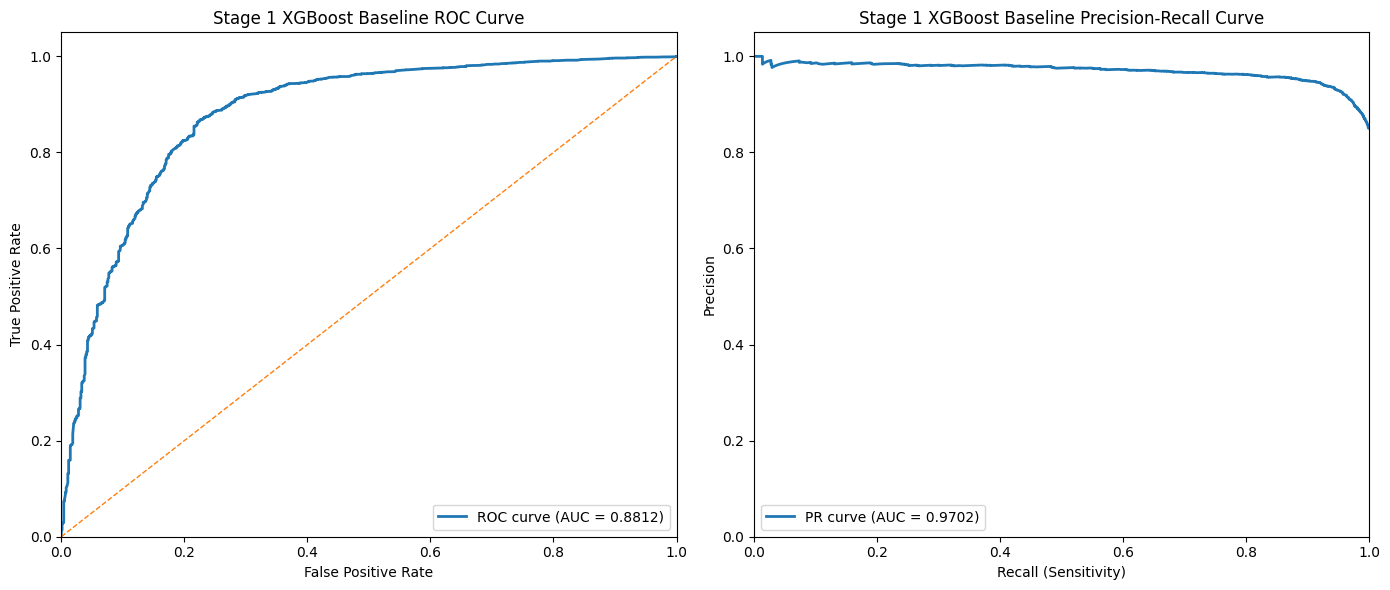

In [55]:
plot_single_model_roc_pr(
    y_true=y_test,
    y_pred_proba=xgb_stage1_baseline["y_pred_proba"],
    title_prefix="Stage 1 XGBoost Baseline"
)

### Confusion Matrix

In [17]:
# ---------------------------------------------------------------------------- #
#                   Function for creating a confusion matrix                   #
# ---------------------------------------------------------------------------- #
def plot_confusion_matrix_from_preds(y_true, y_pred, title='Confusion Matrix', figsize=(8, 6)):
    """
    Plot a confusion matrix from true labels and predicted labels.
    """
    conf_matrix = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=figsize)
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=['Predicted Drop (0)', 'Predicted Complete (1)'],
        yticklabels=['Actual Drop (0)', 'Actual Complete (1)']
    )
    plt.title(title)
    plt.ylabel('Actual Course Outcome')
    plt.xlabel('Predicted Course Outcome')
    plt.tight_layout()
    plt.show()

    return conf_matrix

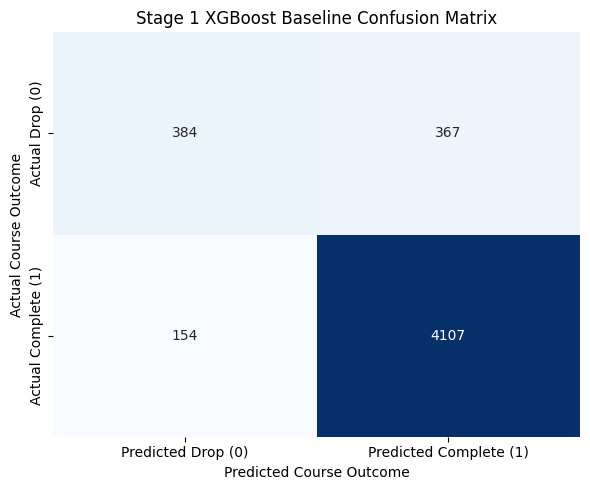

In [31]:
xgb_conf_matrix = plot_confusion_matrix_from_preds(
    y_true=y_test,
    y_pred=xgb_stage1_baseline['y_pred'],
    title='Stage 1 XGBoost Baseline Confusion Matrix',
    figsize=(6, 5)
)

**Summary of XGBoost baseline (stage 1)**
- The Stage 1 XGBoost baseline achieved strong overall performance, with Accuracy = 0.8960, Precision = 0.9180, Recall = 0.9639, and AUC = 0.8812.
- The confusion matrix shows that the model correctly classified 384 non-completers and 4107 completers, while making 367 false positive predictions and 154 false negative predictions.
- This indicates that the model was particularly effective at identifying students who completed the course, as reflected in the high recall.
- The ROC curve and AUC of 0.8812 suggest good overall discrimination between completers and non-completers.
- The Precision-Recall curve also remains strong across most recall levels, indicating that the model maintains relatively high precision while identifying the positive class.

## XGBoost model with Hyperparameter tuning

In [18]:
# ---------------------------------------------------------------------------- #
#                  Function to tune XGBoost using GridSearchCV                 #
# ---------------------------------------------------------------------------- #
def train_xgb_tuned(X_train, y_train, X_test, y_test, baseline_results=None,
                    param_grid=None, scoring='accuracy', cv=3,
                    random_state=42, model_name="Tuned XGBoost"):
    """
    Tune XGBoost using GridSearchCV, then evaluate on the test set.
    """
    if param_grid is None:
        param_grid = {
            'learning_rate': [0.01, 0.1, 0.2],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200]
        }

    xgb_base = xgb.XGBClassifier(
        eval_metric='logloss',
        random_state=random_state
    )

    grid_search = GridSearchCV(
        estimator=xgb_base,
        param_grid=param_grid,
        scoring=scoring,
        cv=cv,
        verbose=1,
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_

    print(f"Best Parameters Found: {best_params}")

    results = evaluate_xgb_model(
        model=best_model,
        X_test=X_test,
        y_test=y_test,
        model_name=model_name
    )

    results["best_params"] = best_params
    results["grid_search"] = grid_search

    if baseline_results is not None:
        print("\nChange vs Baseline:")
        print(f"Accuracy Change:  {results['accuracy'] - baseline_results['accuracy']:+.4f}")
        print(f"Precision Change: {results['precision'] - baseline_results['precision']:+.4f}")
        print(f"Recall Change:    {results['recall'] - baseline_results['recall']:+.4f}")
        print(f"AUC Change:       {results['auc'] - baseline_results['auc']:+.4f}")

    return results

In [19]:
# Tuned XGBoost model
xgb_stage1_tuned = train_xgb_tuned(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    baseline_results=xgb_stage1_baseline,
    model_name="Stage 1 Tuned XGBoost"
)

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best Parameters Found: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
Stage 1 Tuned XGBoost Performance Metrics:
Accuracy:  0.8929
Precision: 0.9199
Recall:    0.9573
AUC:       0.8807

Change vs Baseline:
Accuracy Change:  -0.0032
Precision Change: +0.0020
Recall Change:    -0.0066
AUC Change:       -0.0005


**XGBoost Tuned (stage 1) summary:**

Hyperparameter tuning was applied to the Stage 1 XGBoost model using GridSearchCV, with the best parameters found as:
- learning_rate = 0.1
- max_depth = 7
- n_estimators = 200

The tuned model achieved Accuracy = 0.8929, Precision = 0.9199, Recall = 0.9573, and AUC = 0.8807.

### Visual comparison with XGBoost baseline model


In [27]:
# ---------------------------------------------------------------------------- #
#       Function to create a bar chart comparing baseline vs tuned model       #
# ---------------------------------------------------------------------------- #
def plot_model_comparison(baseline_results, tuned_results, title,
                          baseline_label='Baseline',
                          tuned_label='Tuned',
                          y_min=0.85, y_max=1.0,
                          baseline_color=None, tuned_color=None):
    """
    Plot a bar chart comparing baseline vs tuned model performance.
    """
    metrics_labels = ['Accuracy', 'Precision', 'Recall', 'AUC']

    baseline_metrics = [
        baseline_results['accuracy'],
        baseline_results['precision'],
        baseline_results['recall'],
        baseline_results['auc']
    ]

    tuned_metrics = [
        tuned_results['accuracy'],
        tuned_results['precision'],
        tuned_results['recall'],
        tuned_results['auc']
    ]

    x = np.arange(len(metrics_labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))

    rects1 = ax.bar(
        x - width/2, baseline_metrics, width,
        label=baseline_label, color=baseline_color
    )
    rects2 = ax.bar(
        x + width/2, tuned_metrics, width,
        label=tuned_label, color=tuned_color
    )

    ax.set_ylabel('Scores')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_labels)
    ax.legend(loc='upper right')
    ax.set_ylim(y_min, y_max)

    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(
                f'{height:.4f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords='offset points',
                ha='center',
                va='bottom'
            )

    autolabel(rects1)
    autolabel(rects2)

    plt.tight_layout()
    plt.show()

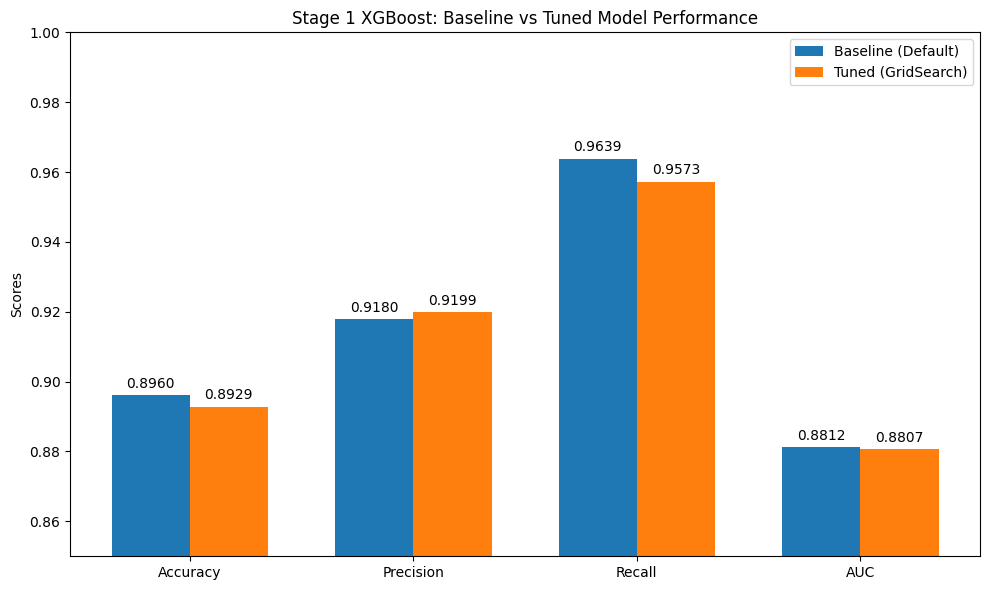

In [35]:
plot_model_comparison(
    baseline_results=xgb_stage1_baseline,
    tuned_results=xgb_stage1_tuned,
    title='Stage 1 XGBoost: Baseline vs Tuned Model Performance',
    baseline_label='Baseline (Default)',
    tuned_label='Tuned (GridSearch)'
)

In [ ]:
# ---------------------------------------------------------------------------- #
#                      Functions to plot ROC and PR curves                     #
# ---------------------------------------------------------------------------- #

def get_curve_data(y_true, y_pred_proba):
    """
    Compute ROC and Precision-Recall curve data plus AUC values.
    """
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc_val = sk_auc(fpr, tpr)

    precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_pred_proba)
    pr_auc_val = sk_auc(recall_vals, precision_vals)

    return {
        "fpr": fpr,
        "tpr": tpr,
        "roc_auc": roc_auc_val,
        "precision_vals": precision_vals,
        "recall_vals": recall_vals,
        "pr_auc": pr_auc_val
    }

def plot_roc_pr_comparison(y_true,
                           y_pred_proba_baseline,
                           y_pred_proba_tuned,
                           title_prefix="Model",
                           baseline_label="Baseline",
                           tuned_label="Tuned"):
    """
    Plot ROC and Precision-Recall curves comparing baseline vs tuned models.
    """
    baseline_curves = get_curve_data(y_true, y_pred_proba_baseline)
    tuned_curves = get_curve_data(y_true, y_pred_proba_tuned)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # ROC Curve
    axes[0].plot(
        baseline_curves["fpr"],
        baseline_curves["tpr"],
        lw=2,
        label=f'{baseline_label} ROC (AUC = {baseline_curves["roc_auc"]:.4f})'
    )
    axes[0].plot(
        tuned_curves["fpr"],
        tuned_curves["tpr"],
        lw=2,
        linestyle='-.',
        label=f'{tuned_label} ROC (AUC = {tuned_curves["roc_auc"]:.4f})'
    )
    axes[0].plot([0, 1], [0, 1], lw=1, linestyle='--')
    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title(f'{title_prefix} ROC Curve Comparison')
    axes[0].legend(loc="lower right")

    # Precision-Recall Curve
    axes[1].plot(
        baseline_curves["recall_vals"],
        baseline_curves["precision_vals"],
        lw=2,
        label=f'{baseline_label} PR (AUC = {baseline_curves["pr_auc"]:.4f})'
    )
    axes[1].plot(
        tuned_curves["recall_vals"],
        tuned_curves["precision_vals"],
        lw=2,
        linestyle='-.',
        label=f'{tuned_label} PR (AUC = {tuned_curves["pr_auc"]:.4f})'
    )
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('Recall (Sensitivity)')
    axes[1].set_ylabel('Precision')
    axes[1].set_title(f'{title_prefix} Precision-Recall Curve Comparison')
    axes[1].legend(loc="lower left")

    plt.tight_layout()
    plt.show()

#### ROC and PR curves

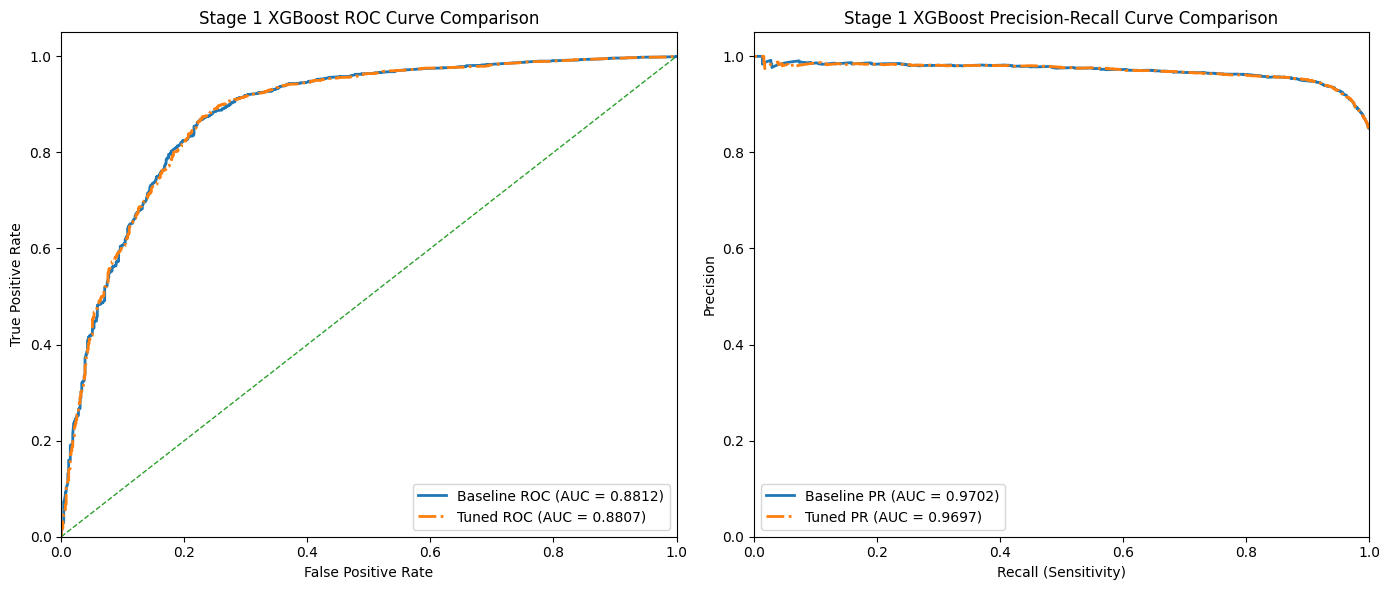

In [41]:
plot_roc_pr_comparison(
    y_true=y_test,
    y_pred_proba_baseline=xgb_stage1_baseline["y_pred_proba"],
    y_pred_proba_tuned=xgb_stage1_tuned["y_pred_proba"],
    title_prefix="Stage 1 XGBoost",
    baseline_label="Baseline",
    tuned_label="Tuned"
)

#### Feature importance


In [ ]:
importance_df_stage1 = plot_xgb_feature_importance(
    model=xgb_stage1_tuned["model"],
    X_train=X_train,
    stage_label="Stage 1: Tuned"
)

#### Confusion Matrix

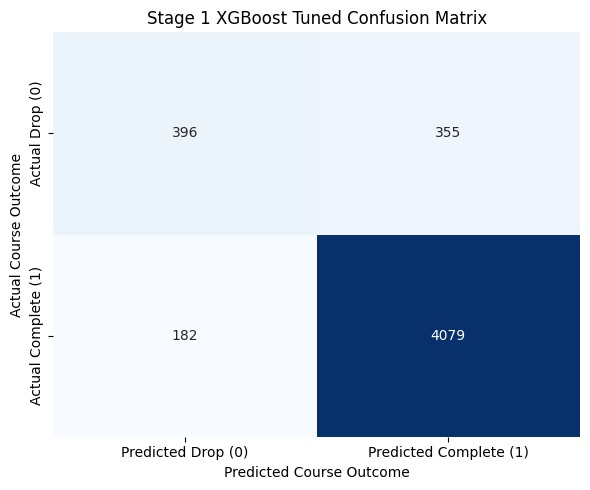

In [ ]:
xgb_conf_matrix_tuned = plot_confusion_matrix_from_preds(
    y_true=y_test,
    y_pred=xgb_stage1_tuned['y_pred'],
    title='Stage 1 XGBoost Tuned Confusion Matrix',
    figsize=(6, 5)
)

**XGBoost baseline and tuned (stage 1) comparison:**

Compared with the baseline model, tuning produced mixed results:
- Precision increased slightly by +0.0020
- Accuracy decreased by -0.0032
- Recall decreased by -0.0066
- AUC decreased slightly by -0.0005

The ROC and Precision-Recall curves for the baseline and tuned models are almost identical, indicating that tuning did not materially change the model’s overall discriminative ability.

This suggests that hyperparameter tuning did not significantly improve the Stage 1 XGBoost model, and the baseline model was already performing close to its best within this search space.

The feature importance plot shows that nationality-related features remained the strongest predictors, with Indian, Bangladeshi, Pakistani contributing most strongly to the tuned model (same as the baseline model).
 

## Neural Network Baseline Model

In [20]:
# Scale numerical features
scaler_stage1 = StandardScaler()
numeric_cols_stage1 = ['Age', 'CourseLevel']
# Create copies of the splits to use specifically for the Neural Network
X_train_nn = X_train.copy()
X_val_nn = X_val.copy()
X_test_nn = X_test.copy()
# Fit the scaler on the training set ONLY, then transform val, and test
X_train_nn[numeric_cols_stage1] = scaler_stage1.fit_transform(X_train_nn[numeric_cols_stage1])
X_val_nn[numeric_cols_stage1] = scaler_stage1.transform(X_val_nn[numeric_cols_stage1])
X_test_nn[numeric_cols_stage1] = scaler_stage1.transform(X_test_nn[numeric_cols_stage1])

In [ ]:
# ---------------------------------------------------------------------------- #
#          Functions to build, compile, train and evaluate a baseline          #
#                             neural network model                             #
# ---------------------------------------------------------------------------- #
def set_random_seeds(seed=42):
    """
    Set Python, NumPy, and TensorFlow random seeds for reproducibility.
    """
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


def build_baseline_nn(input_dim, learning_rate=0.001):
    """
    Build and compile the baseline neural network model.
    """
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


def plot_nn_loss(history, title='Neural Network: Model Loss over Epochs'):
    """
    Plot training and validation loss curves.
    """
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
    plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    plt.title(title)
    plt.ylabel('Loss (Binary Crossentropy)')
    plt.xlabel('Epoch')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


def train_evaluate_nn_baseline(
    X_train_nn,
    y_train,
    X_val_nn,
    y_val,
    X_test_nn,
    y_test,
    model_name='Neural Network Baseline',
    plot_title='Neural Network: Model Loss over Epochs',
    seed=42,
    epochs=50,
    batch_size=32,
    patience=10,
    learning_rate=0.001,
    verbose=1
):
    """
    Train and evaluate a baseline neural network model.

    Returns:
        dict containing model, history, predictions, and evaluation metrics
    """
    print(f"Starting {model_name}...")

    # Set seeds
    set_random_seeds(seed)

    # Convert data to float32 for TensorFlow
    X_train_tf = np.asarray(X_train_nn).astype('float32')
    y_train_tf = np.asarray(y_train).astype('float32')
    X_val_tf = np.asarray(X_val_nn).astype('float32')
    y_val_tf = np.asarray(y_val).astype('float32')
    X_test_tf = np.asarray(X_test_nn).astype('float32')

    print(f"X_train shape: {X_train_tf.shape}")
    print(f"X_val shape:   {X_val_tf.shape}")
    print(f"X_test shape:  {X_test_tf.shape}")

    # Build model
    model = build_baseline_nn(
        input_dim=X_train_tf.shape[1],
        learning_rate=learning_rate
    )

    # Early stopping
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=patience,
        restore_best_weights=True
    )

    # Train
    history = model.fit(
        X_train_tf,
        y_train_tf,
        validation_data=(X_val_tf, y_val_tf),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=verbose
    )

    print(f"\n{model_name} Training Complete.")

    # Plot loss
    plot_nn_loss(history, title=plot_title)

    # Predict
    y_pred_proba = model.predict(X_test_tf, verbose=0).ravel()
    y_pred = (y_pred_proba > 0.5).astype(int)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    auc_score = roc_auc_score(y_test, y_pred_proba)

    print(f"{model_name} Test Set Performance Metrics")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"AUC:       {auc_score:.4f}")

    return {
        'model': model,
        'history': history,
        'X_train_tf': X_train_tf,
        'y_train_tf': y_train_tf,
        'X_val_tf': X_val_tf,
        'y_val_tf': y_val_tf,
        'X_test_tf': X_test_tf,
        'y_pred_proba': y_pred_proba,
        'y_pred': y_pred,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'auc': auc_score
    }

Starting Stage 1 Neural Network Baseline...
X_train shape: (18042, 377)
X_val shape:   (2005, 377)
X_test shape:  (5012, 377)
Epoch 1/50
564/564 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8670 - loss: 0.3116 - val_accuracy: 0.8908 - val_loss: 0.2646
Epoch 2/50
564/564 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8920 - loss: 0.2769 - val_accuracy: 0.8963 - val_loss: 0.2557
Epoch 3/50
564/564 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8947 - loss: 0.2705 - val_accuracy: 0.8988 - val_loss: 0.2524
Epoch 4/50
564/564 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8974 - loss: 0.2632 - val_accuracy: 0.8998 - val_loss: 0.2535
Epoch 5/50
564/564 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9001 - loss: 0.2592 - val_accuracy: 0.8998 - val_loss: 0.2566
Epoch 6/50
564/564 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9000 - loss: 0.2561 - val_accuracy: 0.9017 - val_loss: 0.2552
Epoch 7/50
564/564 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9004 - loss: 0.2510 - val_accuracy: 0.89

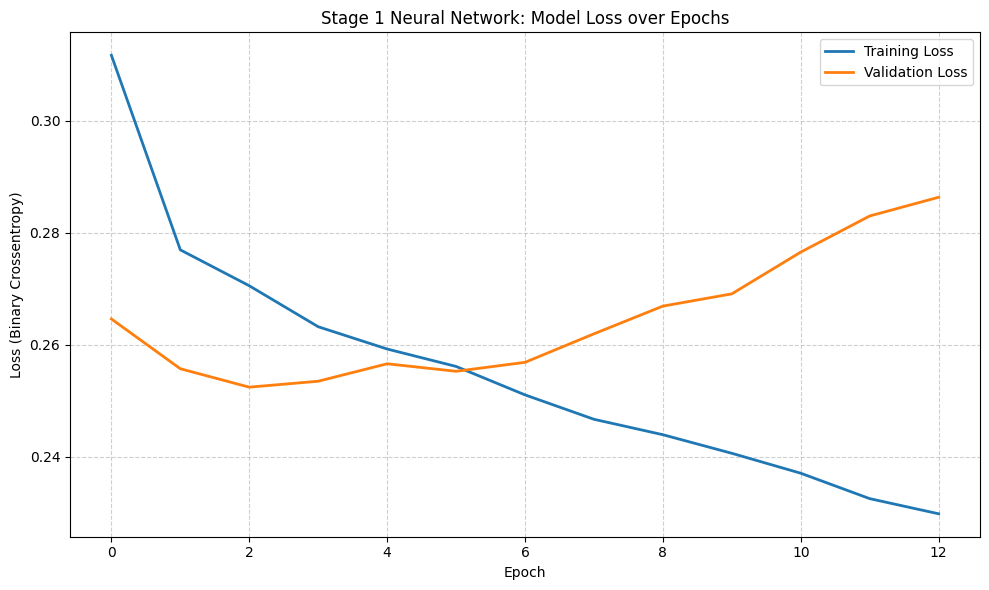

Stage 1 Neural Network Baseline Test Set Performance Metrics
Accuracy:  0.8947
Precision: 0.9156
Recall:    0.9650
AUC:       0.8776


In [22]:
# Instantiate NN stage 1 baseline model
nn_stage1_baseline = train_evaluate_nn_baseline(
    X_train_nn=X_train_nn,
    y_train=y_train,
    X_val_nn=X_val_nn,
    y_val=y_val,
    X_test_nn=X_test_nn,
    y_test=y_test,
    model_name='Stage 1 Neural Network Baseline',
    plot_title='Stage 1 Neural Network: Model Loss over Epochs'
)

#### Confusion Matrix

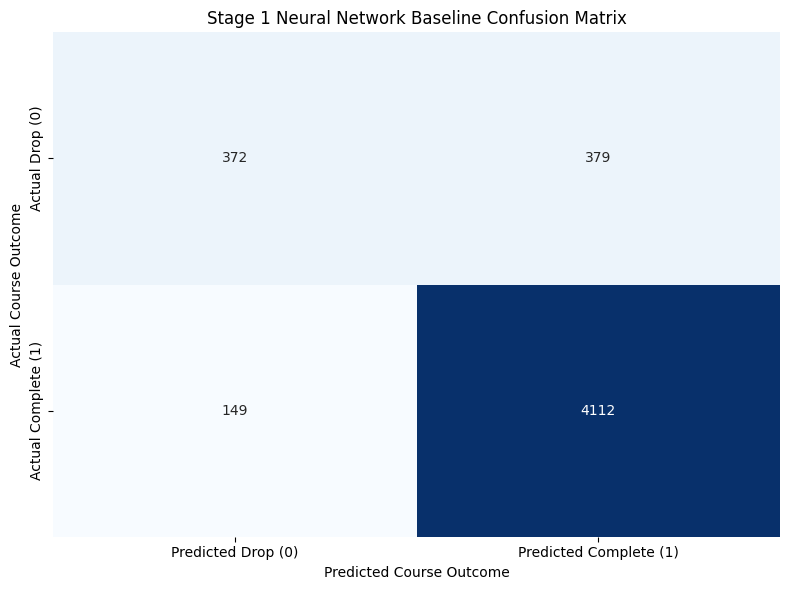

In [ ]:
nn_conf_matrix = plot_confusion_matrix_from_preds(
    y_true=y_test,
    y_pred=nn_stage1_baseline['y_pred'],
    title='Stage 1 Neural Network Baseline Confusion Matrix',
    figsize=(8, 6)
)

**Summary of NN baseline model (stage 1) metrics:** 

- The Stage 1 Neural Network baseline achieved strong overall performance, with Accuracy = 0.8947, Precision = 0.9156, Recall = 0.9650, and AUC = 0.8776.
- The confusion matrix shows that the model correctly classified 372 non-completers and 4112 completers, while making 379 false positive predictions and 149 false negative predictions.
- This indicates that the model was effective at identifying students who completed the course, as reflected in the high recall, but it was less effective at correctly identifying the minority non-completion class.
- The loss curve suggests that the model reaches its best validation performance at approximately epoch 2, after which validation loss begins to increase while training loss continues to decrease, indicating the onset of overfitting.

## Neural Network Hyperparameter Tuning

In [38]:
# ---------------------------------------------------------------------------- #
#          Functions to build and compile a tuned neural network model         #
#           using keras tuner (Hyperband), output performance metrics          #
# ---------------------------------------------------------------------------- #
def build_tunable_nn(hp, input_dim):
    """
    Build and compile a tunable neural network model.
    """
    model = Sequential()

    # Tune hidden layer 1
    hp_units_1 = hp.Choice('units_1', values=[64, 128, 256])

    # Tune activation
    hp_activation = hp.Choice('activation', values=['relu', 'tanh', 'sigmoid'])

    model.add(Dense(hp_units_1, activation=hp_activation, input_shape=(input_dim,)))
    model.add(Dropout(0.2))

    # Tune hidden layer 2
    hp_units_2 = hp.Choice('units_2', values=[32, 64, 128])
    model.add(Dense(hp_units_2, activation=hp_activation))
    model.add(Dropout(0.2))

    # Static layers
    model.add(Dense(32, activation=hp_activation))
    model.add(Dropout(0.2))
    model.add(Dense(16, activation=hp_activation))

    # Output layer
    model.add(Dense(1, activation='sigmoid'))

    # Tune optimiser
    hp_optimizer = hp.Choice('optimizer', values=['adam', 'rmsprop'])
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    if hp_optimizer == 'adam':
        optimizer = tf.keras.optimizers.Adam(learning_rate=hp_learning_rate)
    else:
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=hp_learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )

    return model


def tune_nn_model(
    X_train_tf,
    y_train_tf,
    X_val_tf,
    y_val_tf,
    stage_label="Stage",
    max_epochs=15,
    factor=3,
    patience=5,
    overwrite=True
):
    """
    Run Hyperband tuning for a neural network.

    Returns:
        dict containing tuner and best hyperparameters
    """
    input_dim = X_train_tf.shape[1]

    tuner = kt.Hyperband(
        hypermodel=lambda hp: build_tunable_nn(hp, input_dim=input_dim),
        objective=kt.Objective('val_auc', direction='max'),
        max_epochs=max_epochs,
        factor=factor,
        directory='keras_tuner_dir',
        project_name=f'{stage_label.lower().replace(" ", "_")}_nn_tuning',
        overwrite=overwrite
    )

    stop_early = tf.keras.callbacks.EarlyStopping(
        monitor='val_auc',
        mode='max',
        patience=patience
    )

    print(f"Starting {stage_label} neural network Hyperband search...")

    tuner.search(
        X_train_tf,
        y_train_tf,
        validation_data=(X_val_tf, y_val_tf),
        callbacks=[stop_early],
        verbose=1
    )

    best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

    print(f"\n--- BEST PARAMETERS FOUND ({stage_label}) ---")
    print(f"Layer 1 Neurons: {best_hps.get('units_1')}")
    print(f"Layer 2 Neurons: {best_hps.get('units_2')}")
    print(f"Activation:      {best_hps.get('activation')}")
    print(f"Optimizer:       {best_hps.get('optimizer')}")
    print(f"Learning Rate:   {best_hps.get('learning_rate')}")

    return {
        "tuner": tuner,
        "best_hps": best_hps
    }


def retrain_evaluate_tuned_nn(
    tuner,
    best_hps,
    X_train_tf,
    y_train_tf,
    X_val_tf,
    y_val_tf,
    X_test_tf,
    y_test,
    baseline_results=None,
    model_name="Tuned Neural Network",
    epochs=50,
    batch_size=32,
    patience=5,
    verbose=0
):
    """
    Retrain the best tuned neural network and evaluate it on the test set.

    Returns:
        dict containing model, history, predictions, and evaluation metrics
    """
    best_model = tuner.hypermodel.build(best_hps)

    stop_early_best = tf.keras.callbacks.EarlyStopping(
        monitor='val_auc',
        mode='max',
        patience=patience,
        restore_best_weights=True
    )

    history = best_model.fit(
        X_train_tf,
        y_train_tf,
        validation_data=(X_val_tf, y_val_tf),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[stop_early_best],
        verbose=verbose
    )

    y_pred_proba = best_model.predict(X_test_tf, verbose=0).ravel()
    y_pred = (y_pred_proba > 0.5).astype(int)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    auc_score = roc_auc_score(y_test, y_pred_proba)

    print(f"\n--- {model_name} Test Set Performance ---")
    if baseline_results is None:
        print(f"Accuracy:  {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall:    {recall:.4f}")
        print(f"AUC:       {auc_score:.4f}")
    else:
        print(f"Accuracy:  {accuracy:.4f} (Baseline: {baseline_results['accuracy']:.4f})")
        print(f"Precision: {precision:.4f} (Baseline: {baseline_results['precision']:.4f})")
        print(f"Recall:    {recall:.4f} (Baseline: {baseline_results['recall']:.4f})")
        print(f"AUC:       {auc_score:.4f} (Baseline: {baseline_results['auc']:.4f})")

        print("\nChange vs Baseline:")
        print(f"Accuracy Change:  {accuracy - baseline_results['accuracy']:+.4f}")
        print(f"Precision Change: {precision - baseline_results['precision']:+.4f}")
        print(f"Recall Change:    {recall - baseline_results['recall']:+.4f}")
        print(f"AUC Change:       {auc_score - baseline_results['auc']:+.4f}")

    return {
        "model": best_model,
        "history": history,
        "y_pred_proba": y_pred_proba,
        "y_pred": y_pred,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "auc": auc_score
    }

In [24]:
# Instantiate tuned NN model (Stage 1)
nn_stage1_tuning = tune_nn_model(
    X_train_tf=nn_stage1_baseline['X_train_tf'],
    y_train_tf=nn_stage1_baseline['y_train_tf'],
    X_val_tf=nn_stage1_baseline['X_val_tf'],
    y_val_tf=nn_stage1_baseline['y_val_tf'],
    stage_label="Stage 1"
)

Trial 30 Complete [00h 00m 53s]
val_auc: 0.899851381778717

Best val_auc So Far: 0.899851381778717
Total elapsed time: 00h 08m 25s

--- BEST PARAMETERS FOUND (Stage 1) ---
Layer 1 Neurons: 256
Layer 2 Neurons: 64
Activation:      relu
Optimizer:       adam
Learning Rate:   0.0001


Hyperparameter tuning was applied to the Stage 1 Neural Network using Keras Tuner, with the best configuration identified as:
- Layer 1 neurons: 256
- Layer 2 neurons: 64
- Activation: relu
- Optimizer: adam

Learning rate: 0.001

In [25]:
# Use best parameters from keras tuner (Hyperband) to assess against test data set
nn_stage1_tuned = retrain_evaluate_tuned_nn(
    tuner=nn_stage1_tuning['tuner'],
    best_hps=nn_stage1_tuning['best_hps'],
    X_train_tf=nn_stage1_baseline['X_train_tf'],
    y_train_tf=nn_stage1_baseline['y_train_tf'],
    X_val_tf=nn_stage1_baseline['X_val_tf'],
    y_val_tf=nn_stage1_baseline['y_val_tf'],
    X_test_tf=nn_stage1_baseline['X_test_tf'],
    y_test=y_test,
    baseline_results=nn_stage1_baseline,
    model_name="Stage 1 Tuned Neural Network"
)


--- Stage 1 Tuned Neural Network Test Set Performance ---
Accuracy:  0.8945 (Baseline: 0.8947)
Precision: 0.9174 (Baseline: 0.9156)
Recall:    0.9625 (Baseline: 0.9650)
AUC:       0.8787 (Baseline: 0.8776)

Change vs Baseline:
Accuracy Change:  -0.0002
Precision Change: +0.0018
Recall Change:    -0.0026
AUC Change:       +0.0011


### Visual comparison NN baseline and tuned models (stage 1)

#### ROC and PR curves

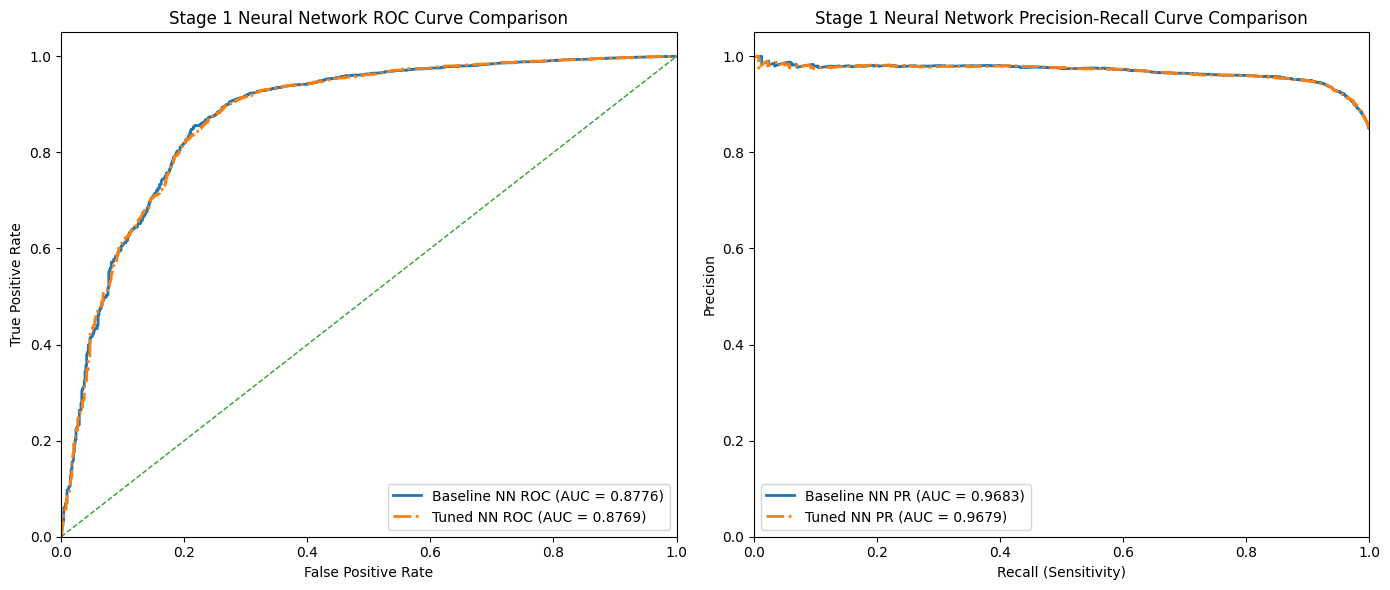

In [54]:
plot_roc_pr_comparison(
    y_true=y_test,
    y_pred_proba_baseline=nn_stage1_baseline["y_pred_proba"],
    y_pred_proba_tuned=nn_stage1_tuned["y_pred_proba"],
    title_prefix="Stage 1 Neural Network",
    baseline_label="Baseline NN",
    tuned_label="Tuned NN"
)

#### Bar chart comparing performance metrics

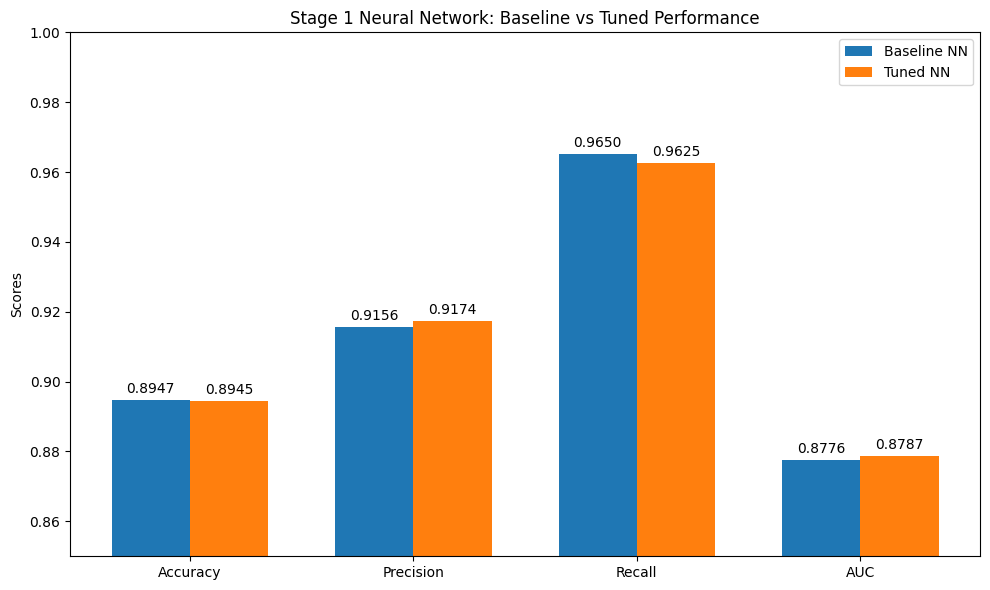

In [28]:
plot_model_comparison(
    baseline_results=nn_stage1_baseline,
    tuned_results=nn_stage1_tuned,
    title='Stage 1 Neural Network: Baseline vs Tuned Performance',
    baseline_label='Baseline NN',
    tuned_label='Tuned NN'
)

#### Confusion Matrix

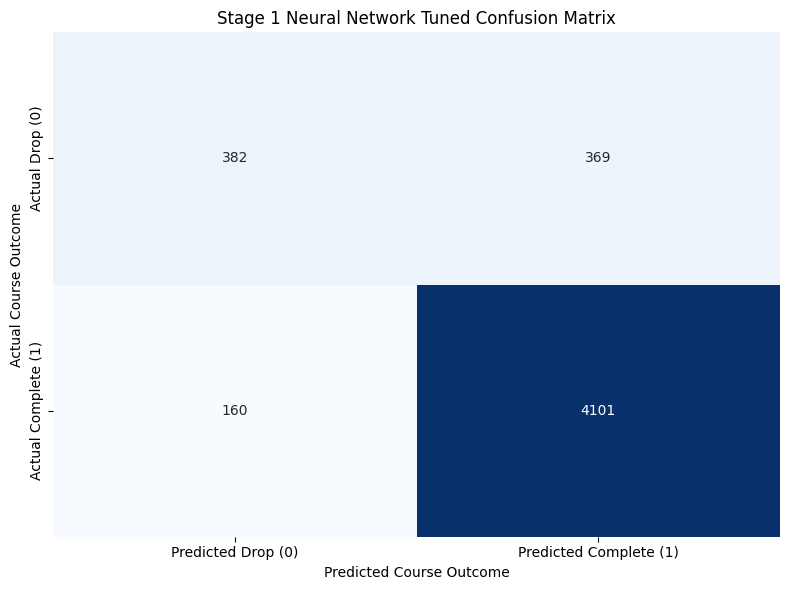

In [31]:
# Generate Confusion Matrix
nn_conf_matrix_tuned = plot_confusion_matrix_from_preds(
    y_true=y_test,
    y_pred=nn_stage1_tuned['y_pred'],
    title='Stage 1 Neural Network Tuned Confusion Matrix',
    figsize=(8, 6)
)

**Summary and comparison of NN baseline and tuned models:**

The tuned model achieved Accuracy = 0.8945, Precision = 0.9174, Recall = 0.9625, and AUC = 0.8787.

Compared with the baseline model, tuning produced only very small changes:
- Accuracy: -0.0002
- Precision: +0.0018
- Recall: -0.0026
- AUC: +0.0011

The ROC and Precision-Recall curves for the baseline and tuned models are almost identical, indicating that tuning did not materially change the model’s ability to distinguish between completers and non-completers.

The tuned confusion matrix shows a slight improvement in identifying non-completers (true negatives increased from 372 to 382), but this came with a small reduction in true positives and recall.

Overall, hyperparameter tuning did not significantly improve the Stage 1 Neural Network, suggesting that the baseline model was already close to its best performance on this feature set.


# Stage 2 data

In [ ]:
# File URL
file_url_2 = os.getenv('FILE_URL_2')

**Stage 2: Pre-processing instructions**

- Remove any columns not useful in the analysis (LearnerCode).
- Remove columns with categorical features with high cardinality (use >200 unique values, as a guideline for this data set).
- Remove columns with >50% data missing.
- Perform ordinal encoding for ordinal data.
- Perform one-hot encoding for all other categorical data.
- Choose how to engage with missing values, which can be done in one of two ways for this project:
  *   Impute the rows with appropriate values.
  *   Remove rows with missing values but ONLY in cases where rows with missing values are minimal: <2% of the overall data.



In [ ]:
# Load dataset
df_stage2 = pd.read_csv(file_url_2)

# Check data has loaded 
df_stage2.head(5)

## Stage 2: Exploratory Data Analysis (EDA)

In [ ]:
# Basic data exploration. Check shape and missing vals
print(f"Number of observations: {df_stage2.shape[0]}")
print(f"Number of features: {df_stage2.shape[1]}")
print(f"Number of duplicates: {df_stage2.duplicated().sum()}")

print("\n--- Data types ---")
display(df_stage2.info())

print("\n--- Missing Values ---")
display(df_stage2.isnull().sum()[df_stage2.isnull().sum() > 0])

**Summary:**

The dataset includes a mix of numeric, boolean, and categorical variables, with no duplicate records identified.

This stage expands the earlier feature set by adding new engagement-related variables, providing additional behavioural signal for modelling.

### EDA on new features

In [ ]:
df_stage2[['engagement_feature_1', 'engagement_feature_2']].describe().round(2)

In [ ]:
# Hist plots for discrete absence count features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

features = ['engagement_feature_1', 'engagement_feature_2']
titles = ['engagement_feature_1 Distribution', 'engagement_feature_2 Distribution']

for ax, feature, title in zip(axes, features, titles):
    data = df_stage2[feature].dropna()
    bins = range(int(data.min()), int(data.max()) + 2)

    sns.histplot(data, bins=bins, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(feature)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

## Data Pre-processing (Stage 2)


In [ ]:
df_stage2 = df_stage2.copy()

# Drop identifier column
if 'record_id' in df_stage2.columns:
    df_stage2.drop(columns=['record_id'], inplace=True)

In [ ]:
# Remove features with more than 50% missing data
missing_percent = df_stage2.isnull().mean()
cols_to_drop_missing = missing_percent[missing_percent > 0.5].index.tolist()
print(f"Dropping columns with >50% missing data: {cols_to_drop_missing}")

df_stage2.drop(columns=cols_to_drop_missing, inplace=True)
print(f"Shape after dropping high-missing columns: {df_stage2.shape}")

### Feature Engineering

In [ ]:
# Convert date of birth to Age before checking for high cardinality
df_stage2['DateofBirth'] = pd.to_datetime(df_stage2['DateofBirth'], dayfirst=True, errors='coerce')
df_stage2['Age'] = pd.Timestamp.now().year - df_stage2['DateofBirth'].dt.year
df_stage2.drop(columns=['DateofBirth'], inplace=True)

df_stage2.head(5)

In [ ]:
# Remove categorical features with high cardinality (200+)
categorical_features = df_stage2.select_dtypes(include=['object']).columns
cardinality = df_stage2[categorical_features].nunique()
display(cardinality)

cols_to_drop_cardinality = cardinality[cardinality > 200].index.tolist()
print(f"Dropping categorical columns with >200 unique values: {cols_to_drop_cardinality}")

df_stage2.drop(columns=cols_to_drop_cardinality, inplace=True)
print(f"Shape after dropping high-cardinality columns: {df_stage2.shape}")

#### Binary encoding - Target variable

In [ ]:
# Convert target variable (CompletedCourse) to binary encoding
target_val_counts = df_stage2['CompletedCourse'].value_counts(dropna=False)
print(f"\nTarget Variable ('CompletedCourse') value counts before encoding:\n{target_val_counts}")

# Map target to binary
df_stage2['CompletedCourse'] = df_stage2['CompletedCourse'].map({'Yes': 1, 'No': 0})

df_stage2.head(5)

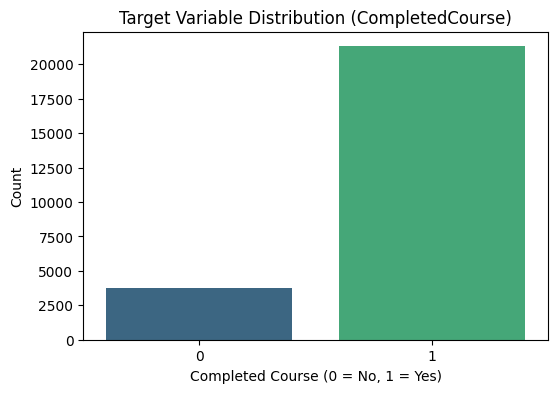

In [40]:
# Check for imbalance
plt.figure(figsize=(6, 4))
sns.countplot(
    data=df_stage2, 
    x='CompletedCourse', 
    hue='CompletedCourse',  
    palette='viridis', 
    legend=False            
)
plt.title('Target Variable Distribution (CompletedCourse)')
plt.xlabel('Completed Course (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()


Data is imbalanced, with the same count as the stage 1 dataset.

### Split Training and Test datasets

In [ ]:
# Separate features (X) and target variable (y)
X_stage2 = df_stage2.drop('CompletedCourse', axis=1)
y_stage2 = df_stage2['CompletedCourse']

# 80% train_temp, 20% test
X_train_temp2, X_test_stage2, y_train_temp2, y_test_stage2 = train_test_split(
    X_stage2, y_stage2, test_size=0.20, random_state=42, stratify=y_stage2
)

# From the 80%, create final train and validation
X_train_stage2, X_val_stage2, y_train_stage2, y_val_stage2 = train_test_split(
    X_train_temp2, y_train_temp2, test_size=0.10, random_state=42, stratify=y_train_temp2
)

print(f"Total dataset shape: {df_stage2.shape}")
print(f"Training set Features: {X_train_stage2.shape}, Target: {y_train_stage2.shape}")
print(f"Validation set Features: {X_val_stage2.shape}, Target: {y_val_stage2.shape}")
print(f"Test set Features: {X_test_stage2.shape}, Target: {y_test_stage2.shape}")


#### Missing values

In [42]:
print("\nMissing values before handling:")
print("X_train_stage2:", X_train_stage2.isna().sum().sum())
print("X_val_stage2:  ", X_val_stage2.isna().sum().sum())
print("X_test_stage2: ", X_test_stage2.isna().sum().sum())


Missing values before handling:
X_train_stage2: 290
X_val_stage2:   46
X_test_stage2:  80


In [ ]:
# Check percentage of rows with at least one missing value in the full Stage 2 dataset
rows_with_missing = df_stage2.isna().any(axis=1).sum()
total_rows = len(df_stage2)
percentage_missing_rows = (rows_with_missing / total_rows) * 100

print(f"Rows with at least one missing value: {rows_with_missing}")
print(f"Total rows: {total_rows}")
print(f"Percentage of rows with missing values: {percentage_missing_rows:.2f}%")

Since the percentage of rows with missing values is only 0.83%, this means that these rows can be dropped as per threshold (<2%) 

In [ ]:
# Drop rows with missing values in each split
train_mask = X_train_stage2.notna().all(axis=1)
val_mask = X_val_stage2.notna().all(axis=1)
test_mask = X_test_stage2.notna().all(axis=1)

X_train_stage2 = X_train_stage2.loc[train_mask].copy()
y_train_stage2 = y_train_stage2.loc[train_mask].copy()

X_val_stage2 = X_val_stage2.loc[val_mask].copy()
y_val_stage2 = y_val_stage2.loc[val_mask].copy()

X_test_stage2 = X_test_stage2.loc[test_mask].copy()
y_test_stage2 = y_test_stage2.loc[test_mask].copy()

print("Shapes after dropping incomplete rows:")
print(f"Training set Features: {X_train_stage2.shape}, Target: {y_train_stage2.shape}")
print(f"Validation set Features: {X_val_stage2.shape}, Target: {y_val_stage2.shape}")
print(f"Test set Features: {X_test_stage2.shape}, Target: {y_test_stage2.shape}")

# Rows were dropped after splitting so that the training, validation, and test targets remained aligned
# with their corresponding feature rows.

#### Ordinal Encoding

In [ ]:
# Ordinal encoding for ordinal features
# Check CourseLevel unique values as this lends itself to ordinal encoding
print(f"Course level unique vals: {df_stage2['CourseLevel'].unique()}")
# Check course level total count
print(f"Course level total count: \n{df_stage2['CourseLevel'].value_counts()}")


In [ ]:
# Ordinal encoding for Stage 2
ordinal_cols_stage2 = ['CourseLevel']

# Create list of categorical features from the training set only
categorical_cols_stage2 = X_train_stage2.select_dtypes(include=['object']).columns.tolist()

# Remove target variable if present
if 'CompletedCourse' in categorical_cols_stage2:
    categorical_cols_stage2.remove('CompletedCourse')

print(f"Categorical features in Stage 2 training set: {categorical_cols_stage2}")

# Define the order for CourseLevel
course_level_order = ['Foundation', 'International Year One', 'International Year Two', 'Pre-Masters']

# Fit ordinal encoder on training data only
ordinal_encoder_stage2 = OrdinalEncoder(
    categories=[course_level_order],
    handle_unknown='use_encoded_value',
    unknown_value=-1,
    dtype=int
)

X_train_stage2[ordinal_cols_stage2] = ordinal_encoder_stage2.fit_transform(X_train_stage2[ordinal_cols_stage2])
X_val_stage2[ordinal_cols_stage2] = ordinal_encoder_stage2.transform(X_val_stage2[ordinal_cols_stage2])
X_test_stage2[ordinal_cols_stage2] = ordinal_encoder_stage2.transform(X_test_stage2[ordinal_cols_stage2])

display(X_train_stage2['CourseLevel'])
print(f"Stage 2 CourseLevel encoded counts (training set):\n{X_train_stage2['CourseLevel'].value_counts()}")


#### One-hot encoding

In [ ]:
# Perform One-hot Encoding for the remaining categorical columns
nominal_cols_stage2 = X_train_stage2.select_dtypes(include=['object']).columns.tolist()

print(f"Nominal columns for one-hot encoding (Stage 2): {nominal_cols_stage2}")

X_train_stage2 = pd.get_dummies(X_train_stage2, columns=nominal_cols_stage2, drop_first=True)
X_val_stage2 = pd.get_dummies(X_val_stage2, columns=nominal_cols_stage2, drop_first=True)
X_test_stage2 = pd.get_dummies(X_test_stage2, columns=nominal_cols_stage2, drop_first=True)

# Align validation and test columns to match training columns
X_val_stage2 = X_val_stage2.reindex(columns=X_train_stage2.columns, fill_value=0)
X_test_stage2 = X_test_stage2.reindex(columns=X_train_stage2.columns, fill_value=0)

print(f"One-hot encoding applied.")
print(f"Training set shape after encoding:   {X_train_stage2.shape}")
print(f"Validation set shape after encoding: {X_val_stage2.shape}")
print(f"Test set shape after encoding:       {X_test_stage2.shape}")

X_train_stage2.head()

## XGBoost baseline model (Stage 2)

In [34]:
xgb_stage2_baseline = train_xgb_baseline(
    X_train=X_train_stage2,
    y_train=y_train_stage2,
    X_val=X_val_stage2,
    y_val=y_val_stage2,
    X_test=X_test_stage2,
    y_test=y_test_stage2,
    model_name="Stage 2 XGBoost Baseline"
)

Stage 2 XGBoost Baseline Performance Metrics:
Accuracy:  0.9055
Precision: 0.9291
Recall:    0.9628
AUC:       0.9092


The Stage 2 XGBoost baseline achieved strong overall performance, with Accuracy = 0.9055, Precision = 0.9291, Recall = 0.9628, and AUC = 0.9092.

### ROC and PR curves

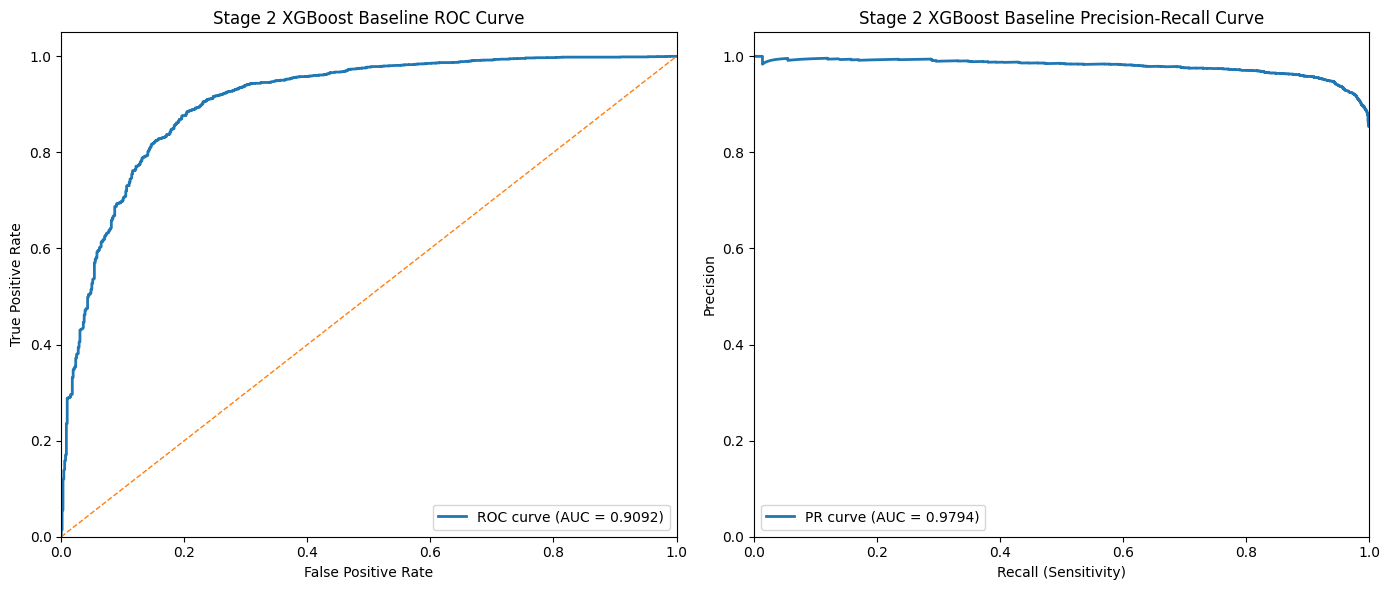

In [52]:
plot_single_model_roc_pr(
    y_true=y_test_stage2,
    y_pred_proba=xgb_stage2_baseline["y_pred_proba"],
    title_prefix="Stage 2 XGBoost Baseline"
)

### Feature Importance

In [ ]:
importance_df_stage2 = plot_xgb_feature_importance(
    model=xgb_stage2_baseline["model"],
    X_train=X_train_stage2,
    stage_label="Stage 2"
)

### Confusion Matrix

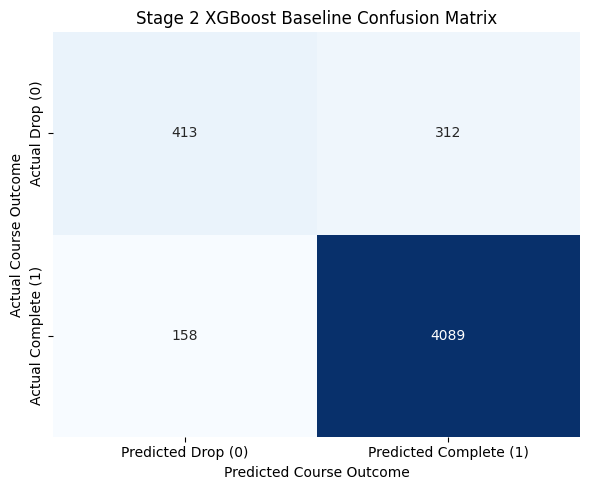

In [36]:
xgb_conf_matrix_stage2 = plot_confusion_matrix_from_preds(
    y_true=y_test_stage2,
    y_pred=xgb_stage2_baseline['y_pred'],
    title='Stage 2 XGBoost Baseline Confusion Matrix',
    figsize=(6, 5)
)

**Summary of XGBoost baseline (Stage 2):**
- The ROC curve and Precision-Recall curve both indicate good class separation, with the model maintaining high precision across most recall levels.
- The feature importance plot suggests that, although nationality related variables remain the strongest predictors, UnauthorisedAbsenceCount also appears among the top features, indicating that attendance behaviour adds meaningful predictive signal in Stage 2.

## Neural Network Baseline (Stage 2)

In [ ]:
# Scale numerical features
scaler_stage2 = StandardScaler()

numeric_cols_stage2 = ['age', 'ordered_category', 'engagement_metric_1', 'engagement_metric_2']

# Create copies of the splits for the neural network
X_train_nn_stage2 = X_train_stage2.copy()
X_val_nn_stage2 = X_val_stage2.copy()
X_test_nn_stage2 = X_test_stage2.copy()

# Fit on training set only, then transform validation and test
X_train_nn_stage2[numeric_cols_stage2] = scaler_stage2.fit_transform(X_train_nn_stage2[numeric_cols_stage2])
X_val_nn_stage2[numeric_cols_stage2] = scaler_stage2.transform(X_val_nn_stage2[numeric_cols_stage2])
X_test_nn_stage2[numeric_cols_stage2] = scaler_stage2.transform(X_test_nn_stage2[numeric_cols_stage2])

Starting Stage 2 Neural Network Baseline...
X_train shape: (17897, 378)
X_val shape:   (1982, 378)
X_test shape:  (4972, 378)
Epoch 1/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8809 - loss: 0.2828 - val_accuracy: 0.9051 - val_loss: 0.2417
Epoch 2/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9036 - loss: 0.2437 - val_accuracy: 0.9036 - val_loss: 0.2360
Epoch 3/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9074 - loss: 0.2368 - val_accuracy: 0.9041 - val_loss: 0.2355
Epoch 4/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9090 - loss: 0.2289 - val_accuracy: 0.9057 - val_loss: 0.2333
Epoch 5/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9107 - loss: 0.2215 - val_accuracy: 0.9092 - val_loss: 0.2344
Epoch 6/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9132 - loss: 0.2153 - val_accuracy: 0.9057 - val_loss: 0.2401
Epoch 7/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9165 - loss: 0.2107 - val_accuracy: 0.91

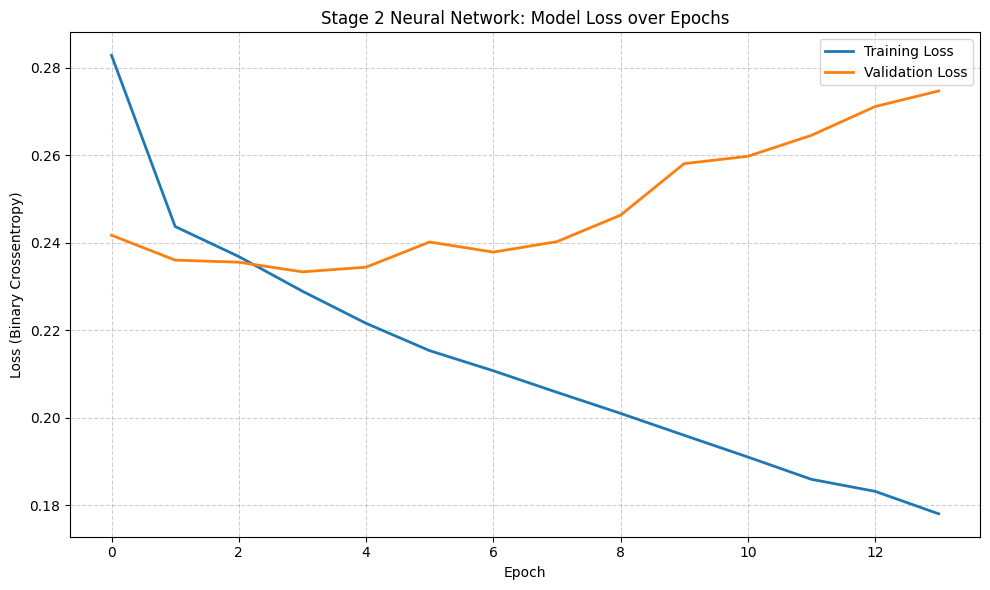

Stage 2 Neural Network Baseline Test Set Performance Metrics
Accuracy:  0.9027
Precision: 0.9383
Recall:    0.9484
AUC:       0.9020


In [34]:
nn_stage2_baseline = train_evaluate_nn_baseline(
    X_train_nn=X_train_nn_stage2,
    y_train=y_train_stage2,
    X_val_nn=X_val_nn_stage2,
    y_val=y_val_stage2,
    X_test_nn=X_test_nn_stage2,
    y_test=y_test_stage2,
    model_name='Stage 2 Neural Network Baseline',
    plot_title='Stage 2 Neural Network: Model Loss over Epochs'
)

### Confusion Matrix

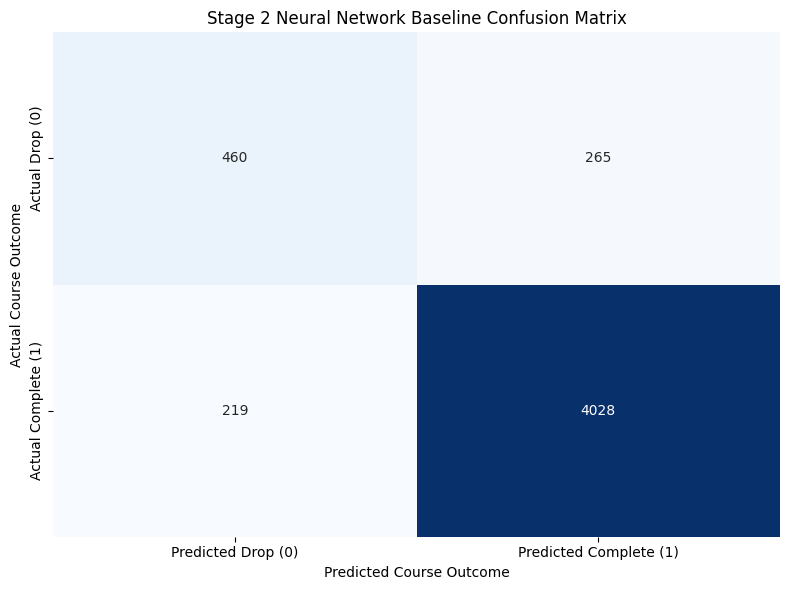

In [ ]:
# Generate Stage 2 Confusion Matrix NN
nn_conf_matrix_stage2 = plot_confusion_matrix_from_preds(
    y_true=y_test_stage2,
    y_pred=nn_stage2_baseline['y_pred'],
    title='Stage 2 Neural Network Baseline Confusion Matrix',
    figsize=(8, 6)
)

**Summary of NN baseline model**
- The Stage 2 Neural Network baseline achieved strong overall performance, with Accuracy = 0.9027, Precision = 0.9383, Recall = 0.9484, and AUC = 0.9020.
- The confusion matrix shows that the Stage 2 Neural Network correctly classified 460 non-completers and 4028 completers, while making 265 false positive predictions and 219 false negative predictions, indicating good overall performance but with some difficulty in distinguishing the minority non-completion class.
- The relatively high precision and recall suggest that the neural network is effective, although its performance remains slightly below the Stage 2 XGBoost model.


## Stage 2 XGBoost and NN Baseline model comparison

In [37]:
# ---------------------------------------------------------------------------- #
#       Functions to build various dataframes displaying metrics between       #
#                                  two stages                                  #
# ---------------------------------------------------------------------------- #
def build_stage_change_df(stage_metrics, from_stage, to_stage):
    """
    Build a dataframe showing metric changes between two stages.

    Parameters:
        stage_metrics (dict): nested dictionary of stage/model metrics
        from_stage (str): e.g. 'Stage 1'
        to_stage (str): e.g. 'Stage 2'

    Returns:
        pd.DataFrame
    """
    rows = []

    common_models = set(stage_metrics[from_stage].keys()).intersection(stage_metrics[to_stage].keys())

    for model_name in common_models:
        from_metrics = stage_metrics[from_stage][model_name]
        to_metrics = stage_metrics[to_stage][model_name]

        rows.append({
            'Model': model_name,
            'Accuracy Change': to_metrics['accuracy'] - from_metrics['accuracy'],
            'Precision Change': to_metrics['precision'] - from_metrics['precision'],
            'Recall Change': to_metrics['recall'] - from_metrics['recall'],
            'AUC Change': to_metrics['auc'] - from_metrics['auc']
        })

    change_df = pd.DataFrame(rows)

    # Format with explicit + / -
    for col in ['Accuracy Change', 'Precision Change', 'Recall Change', 'AUC Change']:
        change_df[col] = change_df[col].map(lambda x: f"{x:+.4f}")

    return change_df
    
def build_stage_comparison_df(stage_metrics):
    """
    Build a comparison dataframe for baseline model performance across stages.

    Parameters:
        stage_metrics (dict): nested dictionary in the format:
            {
                'Stage 1': {
                    'XGBoost': {...},
                    'Neural Network': {...}
                },
                'Stage 2': {
                    'XGBoost': {...},
                    'Neural Network': {...}
                }
            }

    Returns:
        pd.DataFrame
    """
    rows = []

    for stage, models in stage_metrics.items():
        for model_name, metrics in models.items():
            rows.append({
                'Model': model_name,
                'Stage': stage,
                'Accuracy': metrics['accuracy'],
                'Precision': metrics['precision'],
                'Recall': metrics['recall'],
                'AUC': metrics['auc']
            })

    comparison_df = pd.DataFrame(rows)
    return comparison_df.round(4)

def build_stage_change_numeric_df(stage_metrics, from_stage, to_stage):
    """
    Build a numeric dataframe of metric changes between two stages.

    Parameters:
        stage_metrics (dict): nested dictionary of stage/model metrics
        from_stage (str): e.g. 'Stage 1'
        to_stage (str): e.g. 'Stage 2'

    Returns:
        pd.DataFrame: indexed by Model with numeric change columns
    """
    rows = []

    common_models = set(stage_metrics[from_stage].keys()).intersection(stage_metrics[to_stage].keys())

    for model_name in common_models:
        from_metrics = stage_metrics[from_stage][model_name]
        to_metrics = stage_metrics[to_stage][model_name]

        rows.append({
            'Model': model_name,
            'Accuracy Change': to_metrics['accuracy'] - from_metrics['accuracy'],
            'Precision Change': to_metrics['precision'] - from_metrics['precision'],
            'Recall Change': to_metrics['recall'] - from_metrics['recall'],
            'AUC Change': to_metrics['auc'] - from_metrics['auc']
        })

    return pd.DataFrame(rows).set_index('Model')


def build_stage_change_display_df(stage_metrics, from_stage, to_stage):
    """
    Build a formatted dataframe of metric changes between two stages.

    Parameters:
        stage_metrics (dict): nested dictionary of stage/model metrics
        from_stage (str): e.g. 'Stage 1'
        to_stage (str): e.g. 'Stage 2'

    Returns:
        pd.DataFrame: formatted with explicit + / -
    """
    change_df = build_stage_change_numeric_df(stage_metrics, from_stage, to_stage).reset_index()

    for col in ['Accuracy Change', 'Precision Change', 'Recall Change', 'AUC Change']:
        change_df[col] = change_df[col].map(lambda x: f"{x:+.4f}")

    return change_df

In [4]:
# Stage-level performance metrics are hard-coded because the project was completed across separate Colab sessions.
# Since Colab runtimes disconnect and clear objects stored in memory, previously computed metric variables from earlier stages
# were no longer available. There's probably a better way to do this!
stage_metrics = {
    'Stage 1': {
        'XGBoost': {
            'accuracy': 0.8960,
            'precision': 0.9180,
            'recall': 0.9639,
            'auc': 0.8812
        },
        'Neural Network': {
            'accuracy': 0.8947,
            'precision': 0.9156,
            'recall': 0.9650,
            'auc': 0.8776
        }
    },
    'Stage 2': {
        'XGBoost': {
            'accuracy': 0.9055,
            'precision': 0.9291,
            'recall': 0.9628,
            'auc': 0.9092
        },
        'Neural Network': {
            'accuracy': 0.9027,
            'precision': 0.9383,
            'recall': 0.9484,
            'auc': 0.9020
        }
    }
}

stage_metrics_tuned = {
    'Stage 1': {
        'XGBoost': {
            'accuracy': 0.8929,
            'precision': 0.9199,
            'recall': 0.9573,
            'auc': 0.8807
        },
        'Neural Network': {
            'accuracy': 0.8945,
            'precision': 0.9174,
            'recall': 0.9625,
            'auc': 0.8787
        }
    },
    'Stage 2': {
        'XGBoost': {
            'accuracy': 0.9055,
            'precision': 0.9299,
            'recall': 0.9619,
            'auc': 0.9105
        },
        'Neural Network': {
            'accuracy': 0.9039,
            'precision': 0.9319,
            'recall': 0.9574,
            'auc': 0.9040
        }
    }
}

In [38]:
change_df = build_stage_change_df(stage_metrics, from_stage='Stage 1', to_stage='Stage 2')

print("Change in Baseline Model Performance from Stage 1 to Stage 2")
display(change_df)

Change in Baseline Model Performance from Stage 1 to Stage 2


,Model,Accuracy Change,Precision Change,Recall Change,AUC Change
0,Neural Network,+0.0080,+0.0227,-0.0166,+0.0244
1,XGBoost,+0.0095,+0.0111,-0.0011,+0.0280


In [45]:
comparison_df = build_stage_comparison_df(stage_metrics)
display(comparison_df)

,Model,Stage,Accuracy,Precision,Recall,AUC
0,XGBoost,Stage 1,0.8960,0.9180,0.9639,0.8812
1,Neural Network,Stage 1,0.8947,0.9156,0.9650,0.8776
2,XGBoost,Stage 2,0.9055,0.9291,0.9628,0.9092
3,Neural Network,Stage 2,0.9027,0.9383,0.9484,0.9020


In [14]:
# ---------------------------------------------------------------------------- #
#    Functions to build heatmaps comparing performance metrics across stages   #
# ---------------------------------------------------------------------------- #
def plot_stage_comparison_heatmap(comparison_df, title='Performance Comparison'):
    """
    Plot a heatmap of model performance metrics across stages.

    Parameters:
        comparison_df (pd.DataFrame): dataframe with columns
            ['Model', 'Stage', 'Accuracy', 'Precision', 'Recall', 'AUC']
        title (str): plot title
    """
    comparison_heatmap = comparison_df.copy()
    comparison_heatmap['Model_Stage'] = (
        comparison_heatmap['Model'] + ' - ' + comparison_heatmap['Stage']
    )
    comparison_heatmap = comparison_heatmap.set_index('Model_Stage')[
        ['Accuracy', 'Precision', 'Recall', 'AUC']
    ]

    plt.figure(figsize=(8, 4.5))
    sns.heatmap(
        comparison_heatmap,
        annot=True,
        fmt=".4f",
        cmap="Blues",
        cbar=True,
        linewidths=0.5
    )

    plt.title(title)
    plt.ylabel("")
    plt.xlabel("Metric")
    plt.tight_layout()
    plt.show()

def plot_stage_change_heatmap(stage_metrics, from_stage, to_stage, title=None):
    """
    Plot a heatmap showing performance changes between two stages.

    Parameters:
        stage_metrics (dict): nested dictionary of stage/model metrics
        from_stage (str): e.g. 'Stage 1'
        to_stage (str): e.g. 'Stage 2'
        title (str or None): custom plot title
    """
    change_numeric_df = build_stage_change_numeric_df(stage_metrics, from_stage, to_stage)

    if title is None:
        title = f'Change in Performance from {from_stage} to {to_stage}'

    plt.figure(figsize=(8, 3.5))
    sns.heatmap(
        change_numeric_df,
        annot=True,
        fmt="+.4f",
        cmap="RdYlGn",
        center=0,
        cbar=True,
        linewidths=0.5
    )

    plt.title(title)
    plt.ylabel("")
    plt.xlabel("Metric")
    plt.tight_layout()
    plt.show()

### Heatmaps to compare performance

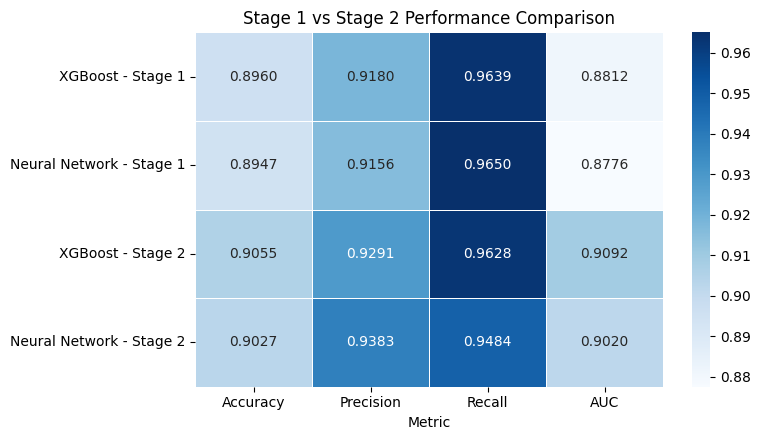

In [46]:
plot_stage_comparison_heatmap(
    comparison_df,
    title='Stage 1 vs Stage 2 Performance Comparison'
)

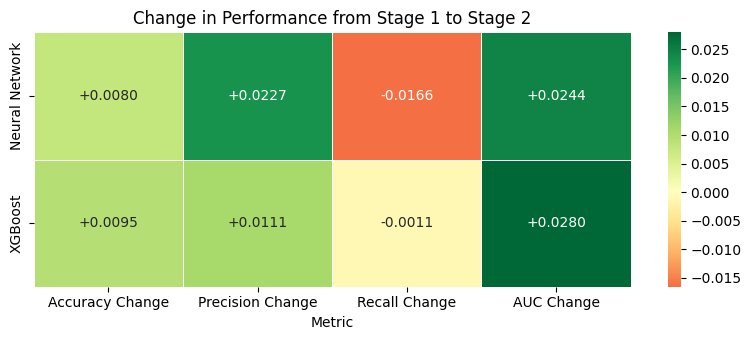

In [48]:
plot_stage_change_heatmap(
    stage_metrics,
    from_stage='Stage 1',
    to_stage='Stage 2'
)

**Comparison of baseline models (Stage 1 vs Stage 2):**

- Both models performed better on Stage 2 than on Stage 1, suggesting that the additional features introduced at this stage provided useful predictive signal.
- XGBoost showed the strongest overall improvement, with gains across all four metrics:
  - Accuracy: +0.0114
  - Precision: +0.0115
  - Recall: +0.0011
  - AUC: +0.0293

- The Neural Network also improved overall, particularly in:
  - Accuracy: +0.0029
  - Precision: +0.0076
  - AUC: +0.0185

- XGBoost achieved the best Stage 2 performance overall, with the highest Accuracy (**0.9063**) and AUC (**0.9106**).

**Why the improvement?**

- A likely reason for the improvement is that Stage 2 includes additional engagement-related variables that were not available in Stage 1.
- These features appear to provide extra signal that helps the models distinguish more effectively between the two outcome classes.
- This was also broadly consistent with earlier exploratory analysis, where some of the newly introduced variables showed clearer separation between groups.

## XGBoost model with Hyperparameter tuning (Stage 2)

In [49]:
xgb_stage2_tuned = train_xgb_tuned(
    X_train=X_train_stage2,
    y_train=y_train_stage2,
    X_test=X_test_stage2,
    y_test=y_test_stage2,
    baseline_results=xgb_stage2_baseline,
    model_name="Stage 2 Tuned XGBoost"
)

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best Parameters Found: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Stage 2 Tuned XGBoost Performance Metrics:
Accuracy:  0.9055
Precision: 0.9299
Recall:    0.9619
AUC:       0.9105

Change vs Baseline:
Accuracy Change:  +0.0000
Precision Change: +0.0008
Recall Change:    -0.0009
AUC Change:       +0.0014


Hyperparameter tuning was applied to the Stage 2 XGBoost model using GridSearchCV, with the best parameters found as:
- learning_rate = 0.1
- max_depth = 5
- n_estimators = 200

The tuned model achieved Accuracy = 0.9055, Precision = 0.9299, Recall = 0.9619, and AUC = 0.9105.

### Feature importance

In [ ]:
importance_df_stage1 = plot_xgb_feature_importance(
    model=xgb_stage2_tuned["model"],
    X_train=X_train_stage2,
    stage_label="Stage 2: Tuned"
)

### Bar chart for XGBoost baseline vs tuned accuracy metrics (stage 2)

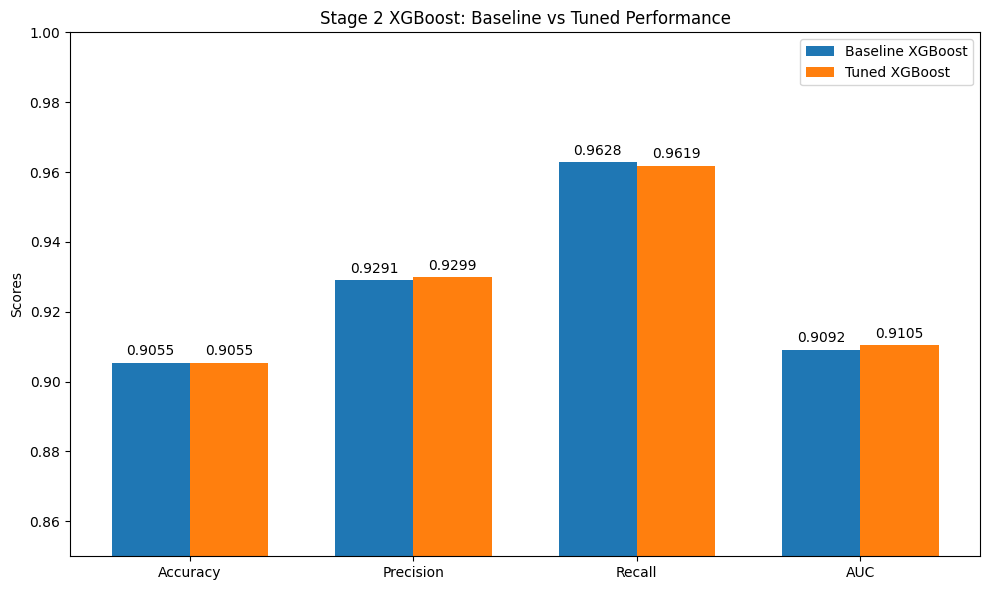

In [56]:
plot_model_comparison(
    baseline_results=xgb_stage2_baseline,
    tuned_results=xgb_stage2_tuned,
    title='Stage 2 XGBoost: Baseline vs Tuned Performance',
    baseline_label='Baseline XGBoost',
    tuned_label='Tuned XGBoost'
)

### ROC and PR curves comparison for baseline and tuned models (Stage 2)

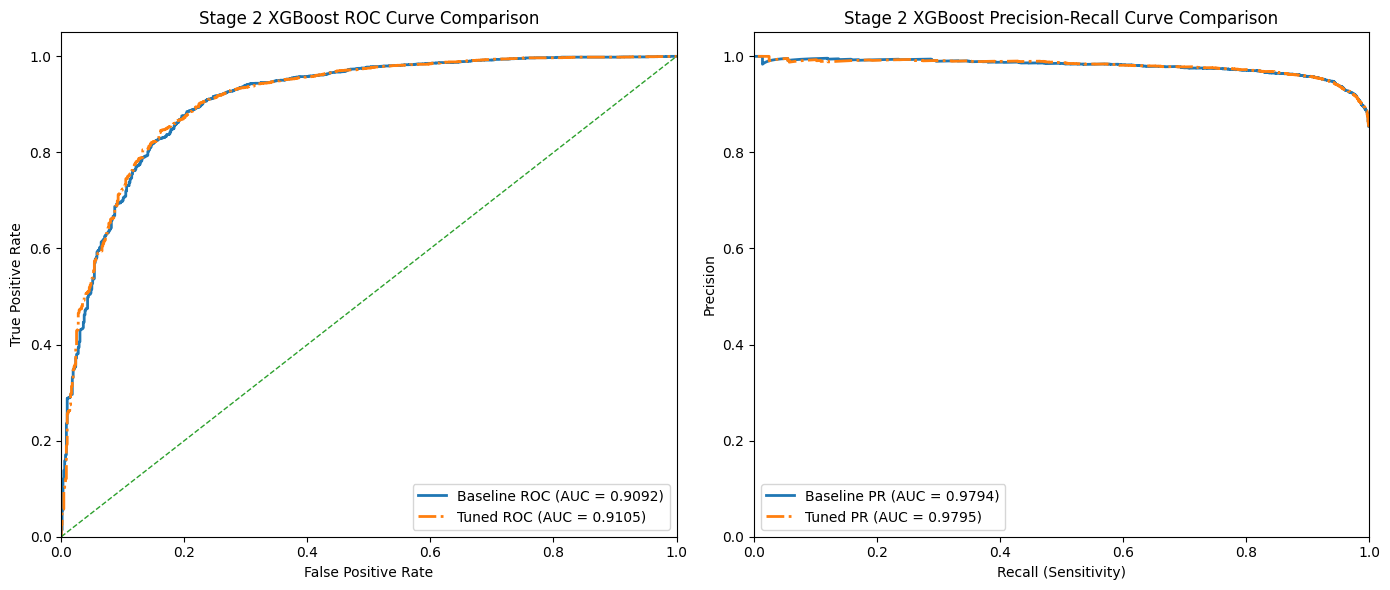

In [69]:
plot_roc_pr_comparison(
    y_true=y_test_stage2,
    y_pred_proba_baseline=xgb_stage2_baseline["y_pred_proba"],
    y_pred_proba_tuned=xgb_stage2_tuned["y_pred_proba"],
    title_prefix="Stage 2 XGBoost",
    baseline_label="Baseline",
    tuned_label="Tuned"
)

### Confusion matrix

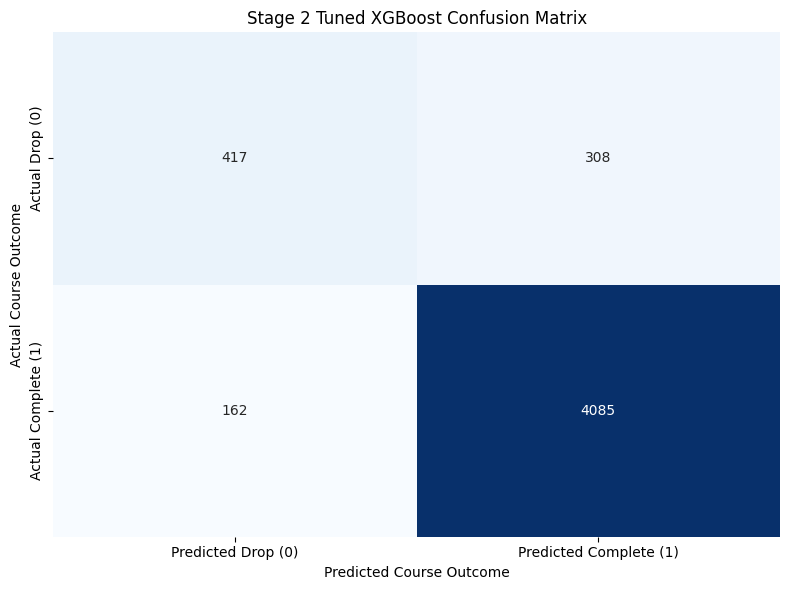

In [67]:
xgb_conf_matrix_tuned_stage2 = plot_confusion_matrix_from_preds(
    y_true=y_test_stage2,
    y_pred=xgb_stage2_tuned['y_pred'],
    title='Stage 2 Tuned XGBoost Confusion Matrix',
    figsize=(8, 6)
)

**Summary of the Tuned XGBoost Model (Stage 2)**

Compared with the Stage 2 baseline XGBoost model, hyperparameter tuning produced only marginal changes in performance:

- Accuracy: +0.0000  
- Precision: +0.0008  
- Recall: -0.0009  
- AUC: +0.0014  

The ROC and Precision-Recall curves for the baseline and tuned models were very similar, indicating that tuning did not materially change the model’s overall discriminative performance.

The confusion matrix for the tuned model was also broadly similar to the baseline model, suggesting that the pattern of correct and incorrect classifications remained largely unchanged.

Feature importance results indicated that a small number of categorical and engagement-related variables continued to contribute strongly to the model’s predictions, consistent with patterns observed earlier in the analysis.

Overall, hyperparameter tuning did not significantly improve the Stage 2 XGBoost model, suggesting that the baseline model was already performing close to its practical optimum on this feature set.

## Neural Network Hyperparameter Tuning (Stage 2)

In [53]:
nn_stage2_tuning = tune_nn_model(
    X_train_tf=nn_stage2_baseline['X_train_tf'],
    y_train_tf=nn_stage2_baseline['y_train_tf'],
    X_val_tf=nn_stage2_baseline['X_val_tf'],
    y_val_tf=nn_stage2_baseline['y_val_tf'],
    stage_label="Stage 2"
)


Trial 30 Complete [00h 01m 00s]
val_auc: 0.9166733622550964

Best val_auc So Far: 0.9166733622550964
Total elapsed time: 00h 08m 40s

--- BEST PARAMETERS FOUND (Stage 2) ---
Layer 1 Neurons: 256
Layer 2 Neurons: 64
Activation:      relu
Optimizer:       adam
Learning Rate:   0.0001


In [54]:
nn_stage2_tuned = retrain_evaluate_tuned_nn(
    tuner=nn_stage2_tuning['tuner'],
    best_hps=nn_stage2_tuning['best_hps'],
    X_train_tf=nn_stage2_baseline['X_train_tf'],
    y_train_tf=nn_stage2_baseline['y_train_tf'],
    X_val_tf=nn_stage2_baseline['X_val_tf'],
    y_val_tf=nn_stage2_baseline['y_val_tf'],
    X_test_tf=nn_stage2_baseline['X_test_tf'],
    y_test=y_test_stage2,
    baseline_results=nn_stage2_baseline,
    model_name="Stage 2 Tuned Neural Network"
)


--- Stage 2 Tuned Neural Network Test Set Performance ---
Accuracy:  0.9039 (Baseline: 0.9027)
Precision: 0.9319 (Baseline: 0.9383)
Recall:    0.9574 (Baseline: 0.9484)
AUC:       0.9040 (Baseline: 0.9020)

Change vs Baseline:
Accuracy Change:  +0.0012
Precision Change: -0.0063
Recall Change:    +0.0089
AUC Change:       +0.0020


Hyperparameter tuning was applied to the Stage 2 Neural Network using Keras Tuner.

The tuned model achieved Accuracy = 0.9039, Precision = 0.9319, Recall = 0.9574, and AUC = 0.9040.

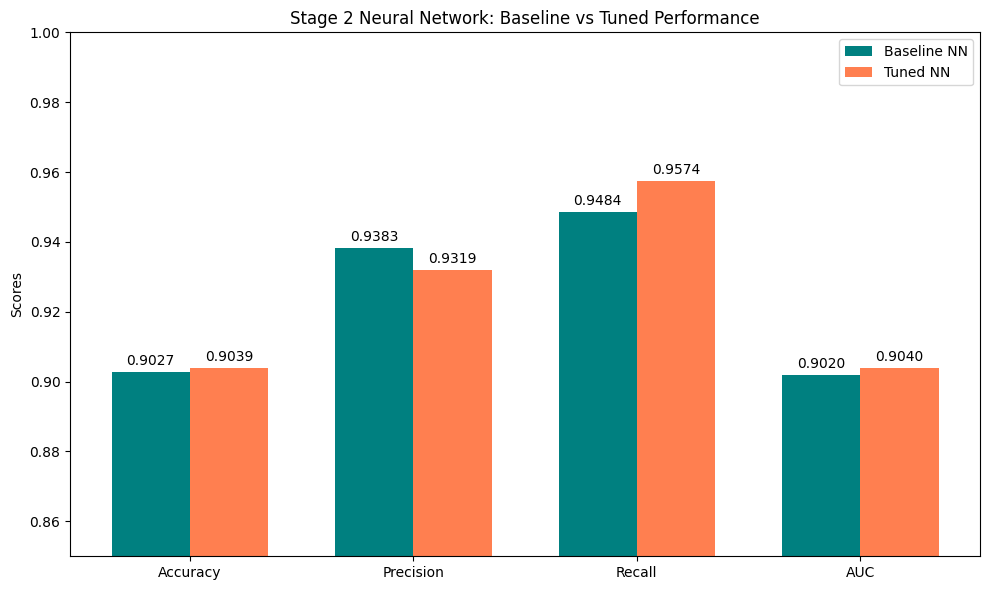

In [62]:
plot_model_comparison(
    baseline_results=nn_stage2_baseline,
    tuned_results=nn_stage2_tuned,
    title='Stage 2 Neural Network: Baseline vs Tuned Performance',
    baseline_label='Baseline NN',
    tuned_label='Tuned NN',
    baseline_color='teal',
    tuned_color='coral'
)

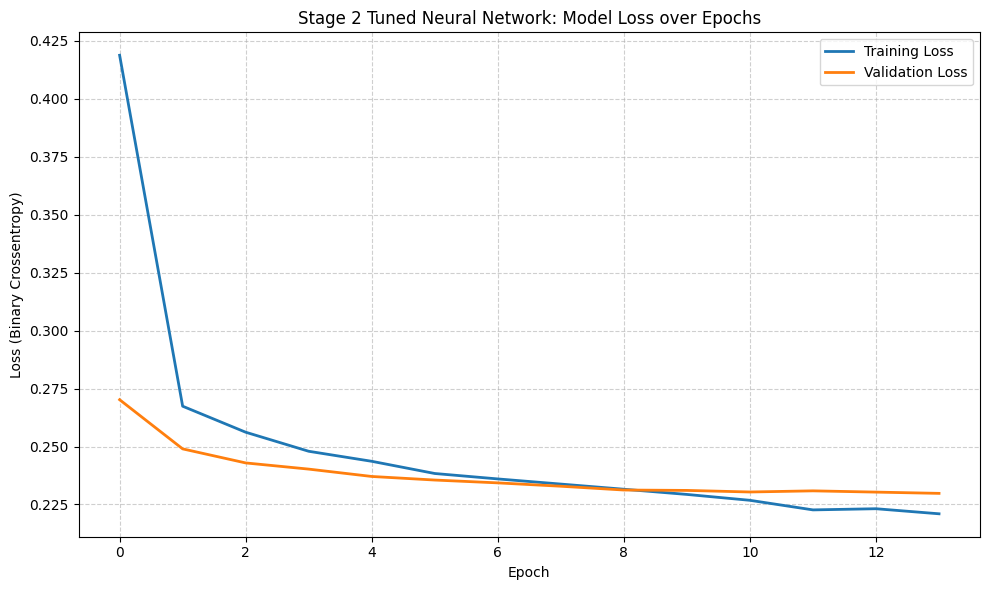

In [60]:
plot_nn_loss(
    nn_stage2_tuned['history'],
    title='Stage 2 Tuned Neural Network: Model Loss over Epochs'
)

### ROC and PR curves

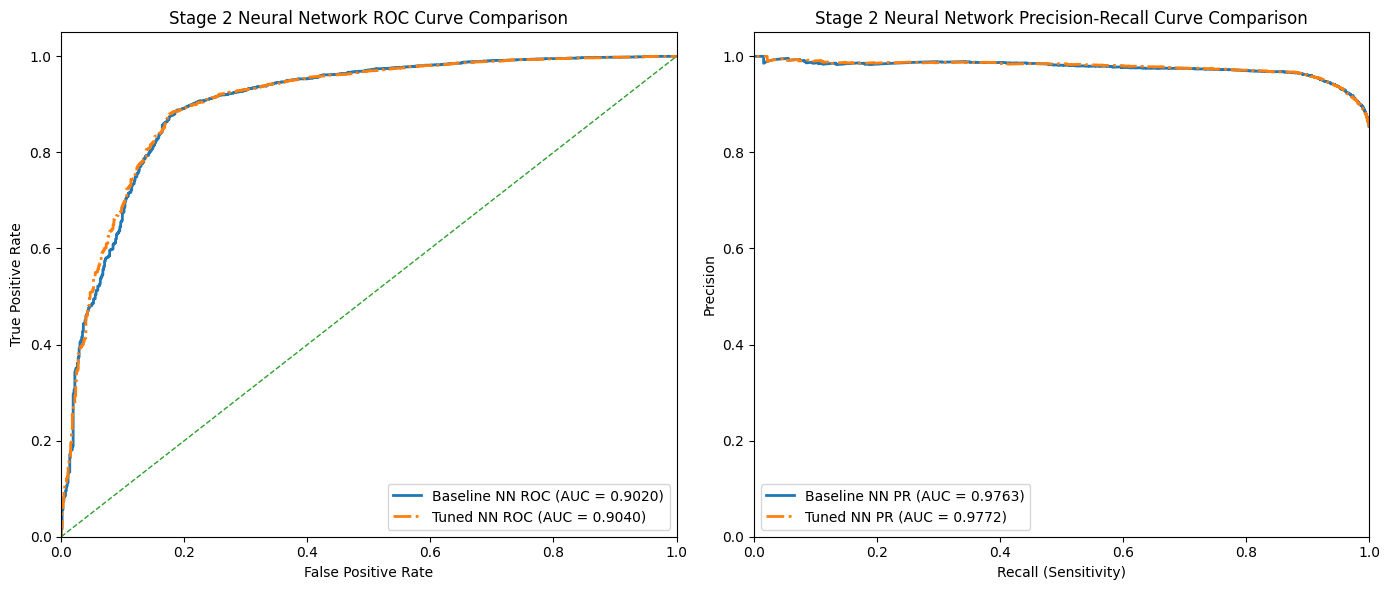

In [66]:
plot_roc_pr_comparison(
    y_true=y_test_stage2,
    y_pred_proba_baseline=nn_stage2_baseline["y_pred_proba"],
    y_pred_proba_tuned=nn_stage2_tuned["y_pred_proba"],
    title_prefix="Stage 2 Neural Network",
    baseline_label="Baseline NN",
    tuned_label="Tuned NN"
)

### Confusion matrix

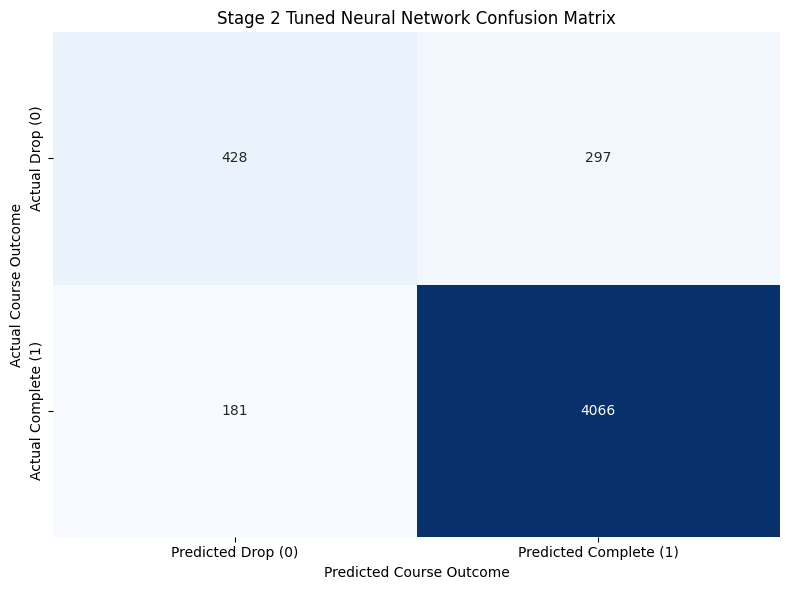

In [68]:
nn_conf_matrix_tuned_stage2 = plot_confusion_matrix_from_preds(
    y_true=y_test_stage2,
    y_pred=nn_stage2_tuned['y_pred'],
    title='Stage 2 Tuned Neural Network Confusion Matrix',
    figsize=(8, 6)
)

**Summary of NN tuned model (Stage 2):**

Compared with the baseline Stage 2 Neural Network, tuning produced small mixed changes:
- Accuracy: +0.0012
- Precision: -0.0063
- Recall: +0.0089
- AUC: +0.0020

This suggests that tuning slightly improved the model’s ability to identify the positive class, as seen in the increase in recall and AUC, but this came at the cost of a small reduction in precision.

The ROC and Precision-Recall curves for the baseline and tuned models are very similar, indicating that the overall discriminative improvement is modest.

The tuned loss curve is more stable than the Stage 2 baseline loss curve, with training and validation loss remaining closer together, suggesting that the tuned model generalises slightly better.

Overall, hyperparameter tuning produced only marginal improvement for the Stage 2 Neural Network and therefore did not significantly enhance performance.

## Comparison of tuned models (stage 2)

Hyperparameter tuning was applied to both the Stage 2 XGBoost and Stage 2 Neural Network models to assess whether performance could be improved beyond the baseline models.

For XGBoost, tuning produced almost no material improvement:
- Accuracy: no change (+0.0000)
- Precision: slight increase (+0.0008)
- Recall: slight decrease (-0.0009)
- AUC: very small increase (+0.0014)

These changes are extremely small, so hyperparameter tuning did not significantly improve the Stage 2 XGBoost model. This suggests the baseline XGBoost model was already performing close to optimally on this dataset.

For the Neural Network, tuning produced small but slightly more noticeable changes:
- Accuracy: slight increase (+0.0012)
- Precision: decrease (-0.0063)
- Recall: increase (+0.0089)
- AUC: slight increase (+0.0020)

The tuned Neural Network became better at identifying completers/non-completers overall, as shown by the improvements in recall and AUC, but this came at the cost of a small drop in precision.

Overall, hyperparameter tuning led to only marginal improvements for both models, and therefore did not significantly enhance performance on the Stage 2 dataset.

Among the two tuned models, the Neural Network showed a slightly more meaningful trade-off, improving recall and AUC, whereas XGBoost remained almost unchanged after tuning.

# Stage 3 data

In [58]:
# File URL
file_url_3 = os.getenv('FILE_URL_3')

**Stage 3: Pre-processing instructions**

- Remove any columns not useful in the analysis (LearnerCode).
- Remove columns with categorical features with high cardinality (use >200 unique values, as a guideline for this data set).
- Remove columns with >50% data missing.
- Perform ordinal encoding for ordinal data.
- Perform one-hot encoding for all other categorical data.
- Choose how to engage with rows that have missing values, which can be done in one of two ways for this project:
  *   Impute the rows with appropriate values.
  *   Remove rows with missing values but ONLY in cases where rows with missing values are minimal: <2% of the overall data.

In [ ]:
# Load dataset
df_stage3 = pd.read_csv(file_url_3)

# Check data has loaded 
df_stage3.head(5)

## Stage 3: Exploratory Data Analysis (EDA)

In [ ]:
# Basic data exploration. Check shape and missing vals
print(f"Number of observations: {df_stage3.shape[0]}")
print(f"Number of features: {df_stage3.shape[1]}")
print(f"Number of duplicates: {df_stage3.duplicated().sum()}")

print("\n--- Data types ---")
display(df_stage3.info())

print("\n--- Missing Values ---")
display(df_stage3.isnull().sum()[df_stage3.isnull().sum() > 0])

**Summary:**

The dataset contains a mix of numeric, boolean, and categorical variables, with no duplicate records identified.

This stage introduces additional academic progress features, expanding the information available for modelling.

A small group of newly added variables contained missing values and were reviewed during preprocessing.

### EDA on new features


In [ ]:
df_stage3[['academic_metric_1', 'academic_metric_2', 'academic_metric_3']].describe().round(2)

In [ ]:
 # Histogram plots for stage 3 academic features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

features = ['academic_metric_1', 'academic_metric_2', 'academic_metric_3']
titles = [
    'Distribution of Academic Metric 1',
    'Distribution of Academic Metric 2',
    'Distribution of Academic Metric 3'
]

for ax, feature, title in zip(axes, features, titles):
    data = df_stage3[feature].dropna()

    bins = range(int(data.min()), int(data.max()) + 2)

    sns.histplot(data, bins=bins, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(feature)
    ax.set_ylabel('Count')
    ax.set_xticks(range(int(data.min()), int(data.max()) + 1))

plt.tight_layout()
plt.show()

## Data Pre-processing (Stage 3)

In [ ]:
df_stage3 = df_stage3.copy()

# Drop identifier column
if 'record_id' in df_stage3.columns:
    df_stage3.drop(columns=['record_id'], inplace=True)

In [ ]:
# Drop columns with >50% missing values
missing_percent = df_stage3.isnull().mean()
cols_to_drop_missing = missing_percent[missing_percent > 0.5].index.tolist()
print(f"Dropping columns with >50% missing data: {cols_to_drop_missing}")

df_stage3.drop(columns=cols_to_drop_missing, inplace=True)

print(f"Shape after dropping high-missing columns: {df_stage3.shape}")

### Feature Engineering

In [ ]:
# Convert DateofBirth to Age
df_stage3['DateofBirth'] = pd.to_datetime(df_stage3['DateofBirth'], dayfirst=True, errors='coerce')
df_stage3['Age'] = pd.Timestamp.now().year - df_stage3['DateofBirth'].dt.year
df_stage3.drop(columns=['DateofBirth'], inplace=True)

df_stage3.head(5)

In [ ]:
# Remove categorical features with high cardinality (200+)
categorical_features = df_stage3.select_dtypes(include=['object']).columns
cardinality = df_stage3[categorical_features].nunique()
display(cardinality)

cols_to_drop_cardinality = cardinality[cardinality > 200].index.tolist()
print(f"Dropping categorical columns with >200 unique values: {cols_to_drop_cardinality}")

df_stage3.drop(columns=cols_to_drop_cardinality, inplace=True)

print(f"Shape after dropping high-cardinality columns: {df_stage3.shape}")

In [ ]:
# Check missing row %
rows_with_missing_stage3 = df_stage3.isna().any(axis=1).sum()
total_rows_stage3 = len(df_stage3)
percentage_missing_rows_stage3 = (rows_with_missing_stage3 / total_rows_stage3) * 100

print(f"Rows with at least one missing value: {rows_with_missing_stage3}")
print(f"Total rows: {total_rows_stage3}")
print(f"Percentage of rows with missing values: {percentage_missing_rows_stage3:.2f}%")

#### Binary encoding - Target variable

In [ ]:
target_val_counts = df_stage3['CompletedCourse'].value_counts(dropna=False)
print(f"\nTarget Variable ('CompletedCourse') value counts before encoding:\n{target_val_counts}")

df_stage3['CompletedCourse'] = df_stage3['CompletedCourse'].map({'Yes': 1, 'No': 0})

### Split Training and Test datasets

In [ ]:
X_stage3 = df_stage3.drop('CompletedCourse', axis=1)
y_stage3 = df_stage3['CompletedCourse']

X_train_temp3, X_test_stage3, y_train_temp3, y_test_stage3 = train_test_split(
    X_stage3, y_stage3, test_size=0.20, random_state=42, stratify=y_stage3
)

X_train_stage3, X_val_stage3, y_train_stage3, y_val_stage3 = train_test_split(
    X_train_temp3, y_train_temp3, test_size=0.10, random_state=42, stratify=y_train_temp3
)

print(f"Training set Features: {X_train_stage3.shape}, Target: {y_train_stage3.shape}")
print(f"Validation set Features: {X_val_stage3.shape}, Target: {y_val_stage3.shape}")
print(f"Test set Features: {X_test_stage3.shape}, Target: {y_test_stage3.shape}")

In [ ]:
if percentage_missing_rows_stage3 < 2:
    print("Rows with missing values are below 2%, so incomplete rows will be removed.")

    train_mask = X_train_stage3.notna().all(axis=1)
    val_mask = X_val_stage3.notna().all(axis=1)
    test_mask = X_test_stage3.notna().all(axis=1)

    X_train_stage3 = X_train_stage3.loc[train_mask].copy()
    y_train_stage3 = y_train_stage3.loc[train_mask].copy()

    X_val_stage3 = X_val_stage3.loc[val_mask].copy()
    y_val_stage3 = y_val_stage3.loc[val_mask].copy()

    X_test_stage3 = X_test_stage3.loc[test_mask].copy()
    y_test_stage3 = y_test_stage3.loc[test_mask].copy()
else:
    print("Missing rows are 2% or more, so imputation should be used instead.")

print("Missing values after handling:")
print("X_train_stage3:", X_train_stage3.isna().sum().sum())
print("X_val_stage3:  ", X_val_stage3.isna().sum().sum())
print("X_test_stage3: ", X_test_stage3.isna().sum().sum())

### Handling missing values

In [ ]:
# Since missing rows are > 2%, use imputation instead of dropping rows.
print("Missing values before imputation:")
print("X_train_stage3:", X_train_stage3.isna().sum().sum())
print("X_val_stage3:  ", X_val_stage3.isna().sum().sum())
print("X_test_stage3: ", X_test_stage3.isna().sum().sum())

# Separate numeric and categorical columns from training set
numeric_cols_stage3_raw = X_train_stage3.select_dtypes(include=['number', 'bool']).columns.tolist()
categorical_cols_stage3_raw = X_train_stage3.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric columns to impute: {numeric_cols_stage3_raw}")
print(f"Categorical columns to impute: {categorical_cols_stage3_raw}")

# Imputers fitted on training data only
numeric_imputer_stage3 = SimpleImputer(strategy='median')
categorical_imputer_stage3 = SimpleImputer(strategy='most_frequent')

# Impute numeric columns
X_train_stage3[numeric_cols_stage3_raw] = numeric_imputer_stage3.fit_transform(X_train_stage3[numeric_cols_stage3_raw])
X_val_stage3[numeric_cols_stage3_raw] = numeric_imputer_stage3.transform(X_val_stage3[numeric_cols_stage3_raw])
X_test_stage3[numeric_cols_stage3_raw] = numeric_imputer_stage3.transform(X_test_stage3[numeric_cols_stage3_raw])

# Impute categorical columns
X_train_stage3[categorical_cols_stage3_raw] = categorical_imputer_stage3.fit_transform(X_train_stage3[categorical_cols_stage3_raw])
X_val_stage3[categorical_cols_stage3_raw] = categorical_imputer_stage3.transform(X_val_stage3[categorical_cols_stage3_raw])
X_test_stage3[categorical_cols_stage3_raw] = categorical_imputer_stage3.transform(X_test_stage3[categorical_cols_stage3_raw])

print("\nMissing values after imputation:")
print("X_train_stage3:", X_train_stage3.isna().sum().sum())
print("X_val_stage3:  ", X_val_stage3.isna().sum().sum())
print("X_test_stage3: ", X_test_stage3.isna().sum().sum())

### Ordinal Encoding

In [ ]:
ordinal_cols_stage3 = ['ordered_category']
category_order = ['Level 1', 'Level 2', 'Level 3', 'Level 4']

ordinal_encoder_stage3 = OrdinalEncoder(
    categories=[category_order],
    handle_unknown='use_encoded_value',
    unknown_value=-1,
    dtype=int
)

X_train_stage3[ordinal_cols_stage3] = ordinal_encoder_stage3.fit_transform(X_train_stage3[ordinal_cols_stage3])
X_val_stage3[ordinal_cols_stage3] = ordinal_encoder_stage3.transform(X_val_stage3[ordinal_cols_stage3])
X_test_stage3[ordinal_cols_stage3] = ordinal_encoder_stage3.transform(X_test_stage3[ordinal_cols_stage3])

In [ ]:
# Check CourseLevel unique values as this lends itself to ordinal encoding
print(f"Course level unique vals: {df_stage3['CourseLevel'].unique()}")
# Check course level total count
print(f"Course level total count: \n{df_stage3['CourseLevel'].value_counts()}")


### One-hot encoding on remaining categorical features

In [ ]:
nominal_cols_stage3 = X_train_stage3.select_dtypes(include=['object']).columns.tolist()
print(f"Nominal columns for one-hot encoding (Stage 3): {nominal_cols_stage3}")

X_train_stage3 = pd.get_dummies(X_train_stage3, columns=nominal_cols_stage3, drop_first=True)
X_val_stage3 = pd.get_dummies(X_val_stage3, columns=nominal_cols_stage3, drop_first=True)
X_test_stage3 = pd.get_dummies(X_test_stage3, columns=nominal_cols_stage3, drop_first=True)

X_val_stage3 = X_val_stage3.reindex(columns=X_train_stage3.columns, fill_value=0)
X_test_stage3 = X_test_stage3.reindex(columns=X_train_stage3.columns, fill_value=0)

print(f"Training set shape after encoding:   {X_train_stage3.shape}")
print(f"Validation set shape after encoding: {X_val_stage3.shape}")
print(f"Test set shape after encoding:       {X_test_stage3.shape}")

### Prepare the data for neural network

In [71]:
scaler_stage3 = StandardScaler()

numeric_cols_stage3 = [
    'Age',
    'CourseLevel',
    'AssessedModules',
    'PassedModules',
    'FailedModules',
    'AuthorisedAbsenceCount',
    'UnauthorisedAbsenceCount'
]

X_train_nn_stage3 = X_train_stage3.copy()
X_val_nn_stage3 = X_val_stage3.copy()
X_test_nn_stage3 = X_test_stage3.copy()

X_train_nn_stage3 = X_train_nn_stage3.fillna(0)
X_val_nn_stage3 = X_val_nn_stage3.fillna(0)
X_test_nn_stage3 = X_test_nn_stage3.fillna(0)

X_train_nn_stage3[numeric_cols_stage3] = scaler_stage3.fit_transform(X_train_nn_stage3[numeric_cols_stage3])
X_val_nn_stage3[numeric_cols_stage3] = scaler_stage3.transform(X_val_nn_stage3[numeric_cols_stage3])
X_test_nn_stage3[numeric_cols_stage3] = scaler_stage3.transform(X_test_nn_stage3[numeric_cols_stage3])

print("Final NaN check:")
print("X_train_nn_stage3:", X_train_nn_stage3.isna().sum().sum())
print("X_val_nn_stage3:  ", X_val_nn_stage3.isna().sum().sum())
print("X_test_nn_stage3: ", X_test_nn_stage3.isna().sum().sum())

Final NaN check:
X_train_nn_stage3: 0
X_val_nn_stage3:   0
X_test_nn_stage3:  0


Since rows with missing values in Stage 3 exceeded the 2% threshold, missing values were handled through imputation rather than row removal. Numeric variables were imputed using the median, while categorical variables were imputed using the most frequent category, with imputers fitted on the training set only and then applied to validation and test sets

## XGBoost baseline model (Stage 3)

In [72]:
xgb_stage3_baseline = train_xgb_baseline(
    X_train=X_train_stage3,
    y_train=y_train_stage3,
    X_val=X_val_stage3,
    y_val=y_val_stage3,
    X_test=X_test_stage3,
    y_test=y_test_stage3,
    model_name="Stage 3 XGBoost Baseline"
)

Stage 3 XGBoost Baseline Performance Metrics:
Accuracy:  0.9735
Precision: 0.9800
Recall:    0.9890
AUC:       0.9929


### Confusion matrix

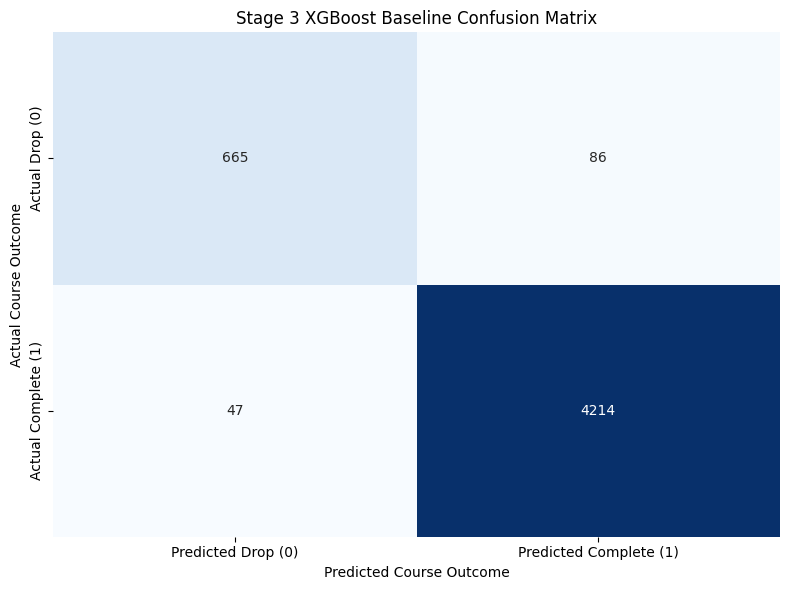

In [73]:
xgb_conf_matrix_stage3 = plot_confusion_matrix_from_preds(
    y_true=y_test_stage3,
    y_pred=xgb_stage3_baseline['y_pred'],
    title='Stage 3 XGBoost Baseline Confusion Matrix',
    figsize=(8, 6)
)

### ROC and PR curves

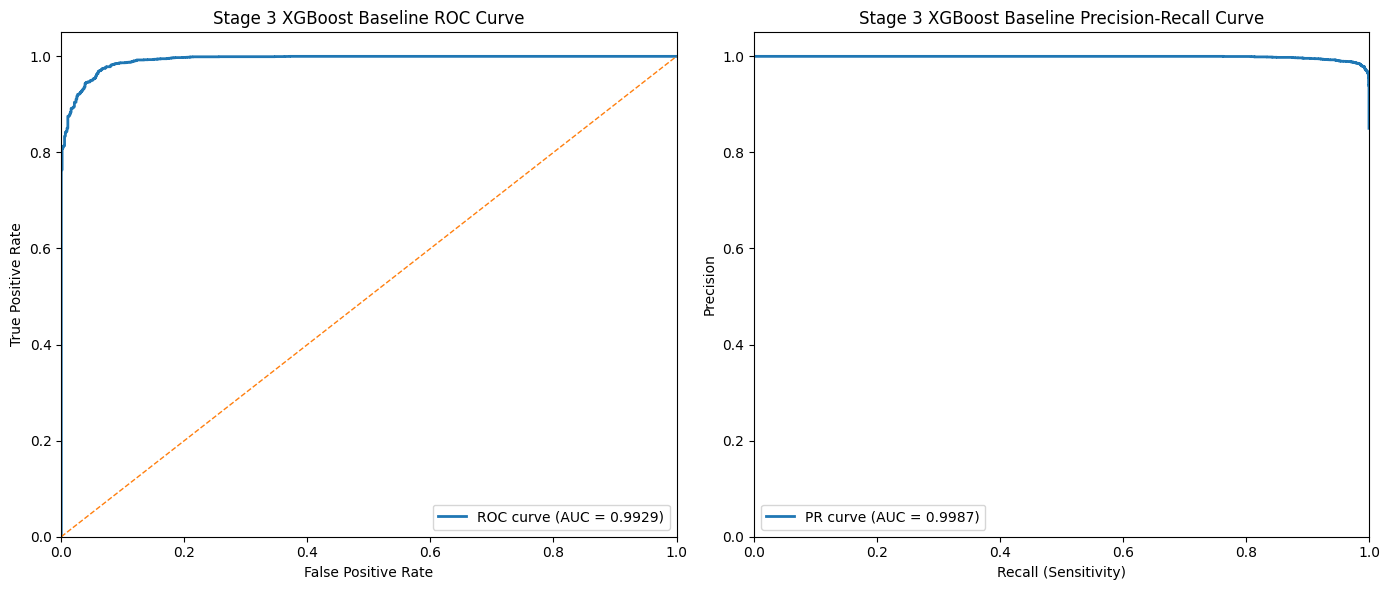

In [50]:
# ROC and PR curves for the baseline model
plot_single_model_roc_pr(
    y_true=y_test_stage3,
    y_pred_proba=xgb_stage3_baseline['y_pred_proba'],
    title_prefix='Stage 3 XGBoost Baseline'
)

### Feature importance

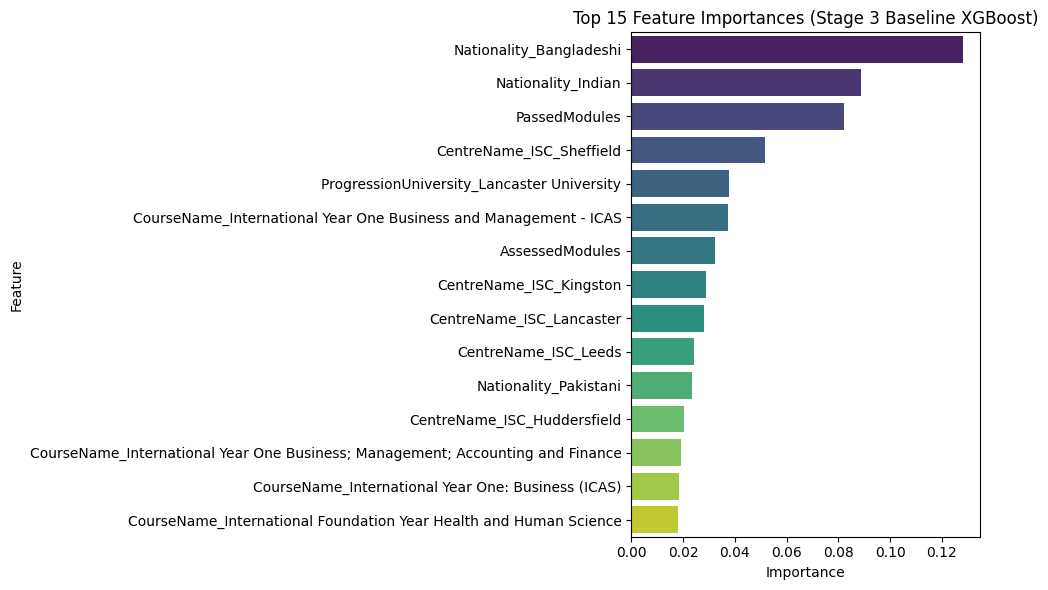

In [57]:
# Feature importance
importance_df_stage3 = plot_xgb_feature_importance(
    model=xgb_stage3_baseline['model'],
    X_train=X_train_stage3,
    stage_label='Stage 3 Baseline'
)

**Summary of XGBoost baseline model (stage 3):**

The Stage 3 XGBoost baseline model performed very strongly, achieving:
- Accuracy: 0.9735
- Precision: 0.9800
- Recall: 0.9890
- AUC: 0.9929

The confusion matrix shows that the model made very few classification errors, with:
- 665 true negatives
- 4214 true positives
- only 86 false positives
- and 47 false negatives

This indicates that the Stage 3 feature set provides substantially stronger predictive signal than earlier stages.

In the feature importance plot, the new academic-performance variables, especially PassedModules, appear among the most influential predictors. Pakistani nationality dropped in importance significantly.

This suggests that module performance is highly informative for predicting course completion, which helps explain the major improvement in model performance relative to Stage 2.

## Neural Network Baseline (Stage 3)

Starting Stage 3 Neural Network Baseline...
X_train shape: (18042, 382)
X_val shape:   (2005, 382)
X_test shape:  (5012, 382)
Epoch 1/50
564/564 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8978 - loss: 0.2336 - val_accuracy: 0.9596 - val_loss: 0.1320
Epoch 2/50
564/564 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9606 - loss: 0.1142 - val_accuracy: 0.9726 - val_loss: 0.0788
Epoch 3/50
564/564 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9685 - loss: 0.0921 - val_accuracy: 0.9776 - val_loss: 0.0678
Epoch 4/50
564/564 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9732 - loss: 0.0772 - val_accuracy: 0.9761 - val_loss: 0.0664
Epoch 5/50
564/564 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9746 - loss: 0.0696 - val_accuracy: 0.9796 - val_loss: 0.0626
Epoch 6/50
564/564 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9767 - loss: 0.0668 - val_accuracy: 0.9771 - val_loss: 0.0643
Epoch 7/50
564/564 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9756 - loss: 0.0638 - val_accuracy: 0.97

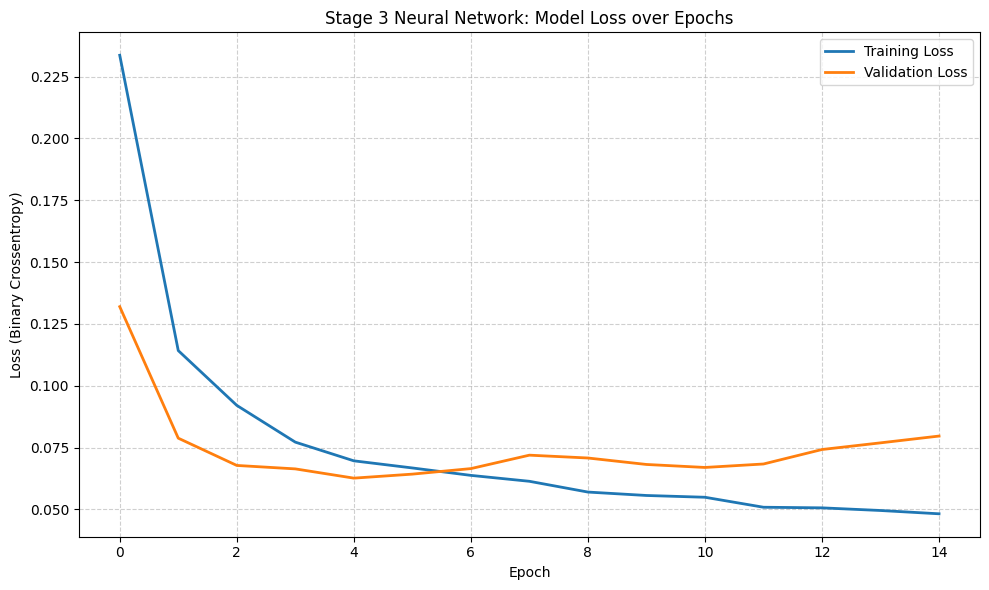

Stage 3 Neural Network Baseline Test Set Performance Metrics
Accuracy:  0.9703
Precision: 0.9770
Recall:    0.9883
AUC:       0.9883


In [83]:
nn_stage3_baseline = train_evaluate_nn_baseline(
    X_train_nn=X_train_nn_stage3,
    y_train=y_train_stage3,
    X_val_nn=X_val_nn_stage3,
    y_val=y_val_stage3,
    X_test_nn=X_test_nn_stage3,
    y_test=y_test_stage3,
    model_name='Stage 3 Neural Network Baseline',
    plot_title='Stage 3 Neural Network: Model Loss over Epochs'
)

The Stage 3 neural network reaches its best validation performance at approximately epoch 4, where validation loss is lowest; after this point, training loss continues to decline while validation loss begins to rise, indicating the onset of overfitting.

### Confusion Matrix

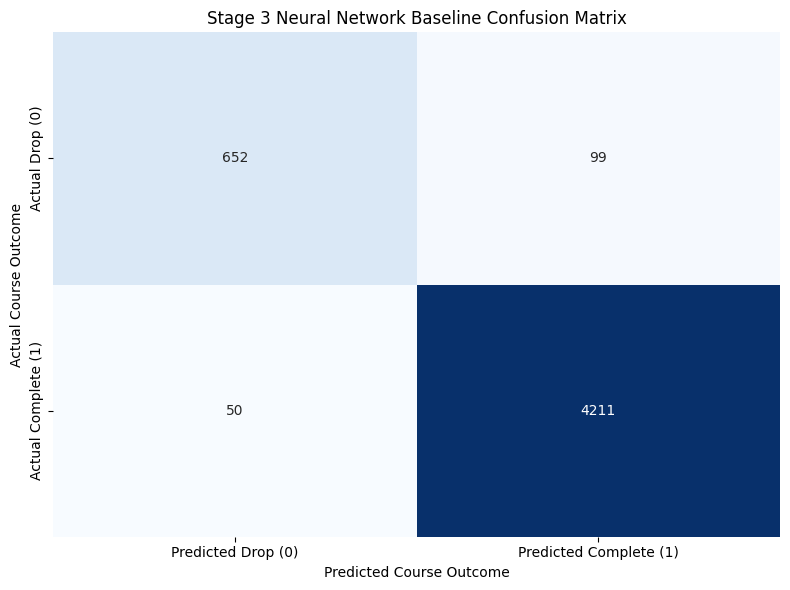

In [ ]:
nn_conf_matrix_stage3 = plot_confusion_matrix_from_preds(
    y_true=y_test_stage3,
    y_pred=nn_stage3_baseline['y_pred'],
    title='Stage 3 Neural Network Baseline Confusion Matrix',
    figsize=(8, 6)
)

### ROC and PR Curves

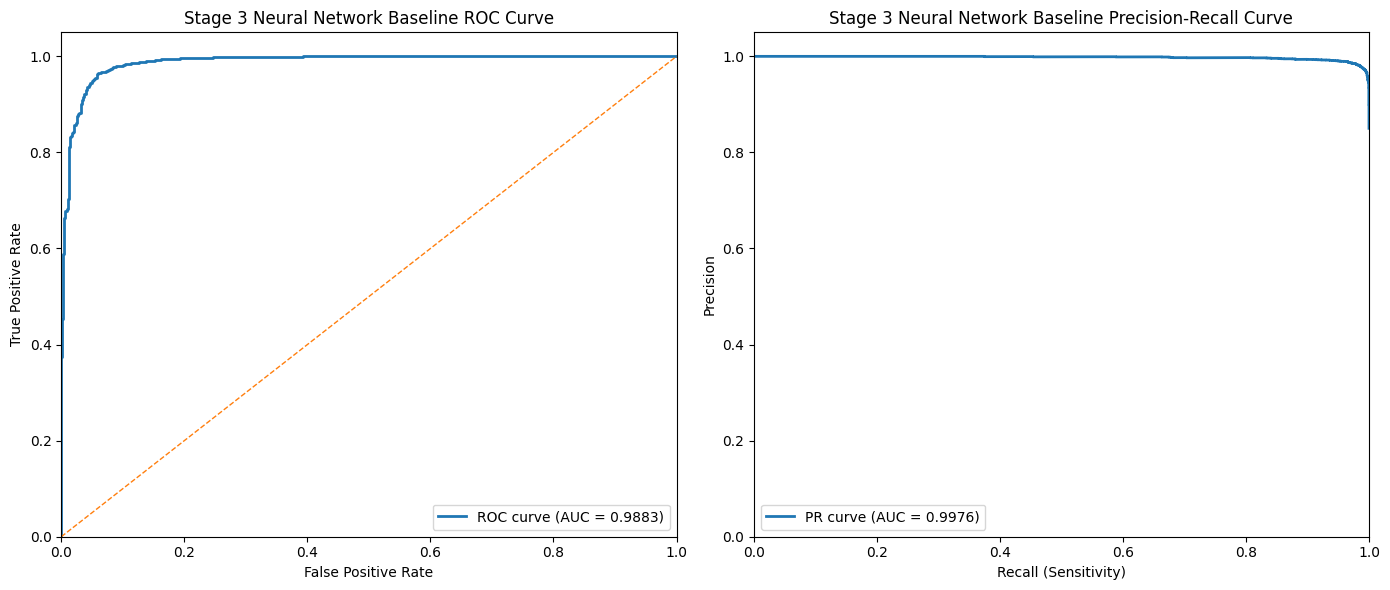

In [61]:
# ROC and PR Curves
plot_single_model_roc_pr(
    y_true=y_test_stage3,
    y_pred_proba=nn_stage3_baseline['y_pred_proba'],
    title_prefix='Stage 3 Neural Network Baseline'
)

**Summary of NN baseline model (Stage 3):**

The Stage 3 Neural Network baseline achieved:
- Accuracy: 0.9703
- Precision: 0.9770
- Recall: 0.9883
- AUC: 0.9883

The confusion matrix shows very few errors, with:
- 652 true negatives
- 4211 true positives
- 99 false positives
- 50 false negatives

The ROC and Precision-Recall curves both indicate excellent class separation, consistent with the very high AUC values.

Compared with the Stage 3 XGBoost baseline, the Neural Network performs slightly worse overall, but still at a very high level.

## Comparison of baseline results (across the stages)

In [90]:
# Add stage metrics to stage metrics dict
stage_metrics['Stage 3'] = {
    'XGBoost': {
        'accuracy': xgb_stage3_baseline['accuracy'],
        'precision': xgb_stage3_baseline['precision'],
        'recall': xgb_stage3_baseline['recall'],
        'auc': xgb_stage3_baseline['auc']
    },
    'Neural Network': {
        'accuracy': nn_stage3_baseline['accuracy'],
        'precision': nn_stage3_baseline['precision'],
        'recall': nn_stage3_baseline['recall'],
        'auc': nn_stage3_baseline['auc']
    }
}

In [91]:
stage_metrics

{'Stage 1': {'XGBoost': {'accuracy': 0.896,
   'precision': 0.918,
   'recall': 0.9639,
   'auc': 0.8812},
  'Neural Network': {'accuracy': 0.8947,
   'precision': 0.9156,
   'recall': 0.965,
   'auc': 0.8776}},
 'Stage 2': {'XGBoost': {'accuracy': 0.9055,
   'precision': 0.9291,
   'recall': 0.9628,
   'auc': 0.9092},
  'Neural Network': {'accuracy': 0.9027,
   'precision': 0.9383,
   'recall': 0.9484,
   'auc': 0.902}},
 'Stage 3': {'XGBoost': {'accuracy': 0.973463687150838,
   'precision': 0.98,
   'recall': 0.9889697254165689,
   'auc': np.float64(0.9928728369996227)},
  'Neural Network': {'accuracy': 0.9702713487629688,
   'precision': 0.977030162412993,
   'recall': 0.9882656653367754,
   'auc': np.float64(0.9882659778357009)}}}

In [ ]:
comparison_df = build_stage_comparison_df(stage_metrics)

print("Stage 2 vs Stage 3 Baseline Model Performance Comparison")
display(comparison_df)

Stage 2 vs Stage 3 Baseline Model Performance Comparison


,Model,Stage,Accuracy,Precision,Recall,AUC
0,XGBoost,Stage 1,0.8960,0.9180,0.9639,0.8812
1,Neural Network,Stage 1,0.8947,0.9156,0.9650,0.8776
2,XGBoost,Stage 2,0.9055,0.9291,0.9628,0.9092
3,Neural Network,Stage 2,0.9027,0.9383,0.9484,0.9020
4,XGBoost,Stage 3,0.9735,0.9800,0.9890,0.9929
5,Neural Network,Stage 3,0.9703,0.9770,0.9883,0.9883


In [ ]:
change_df_2_3 = build_stage_change_display_df(
    stage_metrics,
    from_stage='Stage 2',
    to_stage='Stage 3'
)

print("Change in Baseline Model Performance from Stage 2 to Stage 3")
display(change_df_2_3)

Change in Baseline Model Performance from Stage 2 to Stage 3


,Model,Accuracy Change,Precision Change,Recall Change,AUC Change
0,XGBoost,+0.0680,+0.0509,+0.0262,+0.0837
1,Neural Network,+0.0676,+0.0387,+0.0399,+0.0863


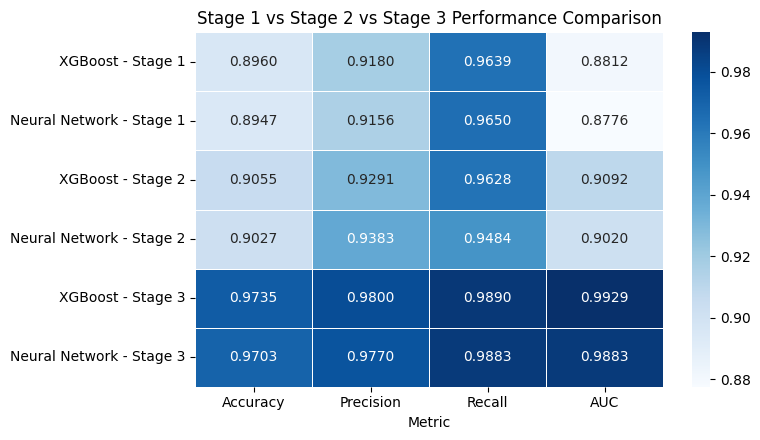

In [ ]:
plot_stage_comparison_heatmap(
    comparison_df,
    title='Stage 1 vs Stage 2 vs Stage 3 Performance Comparison'
)

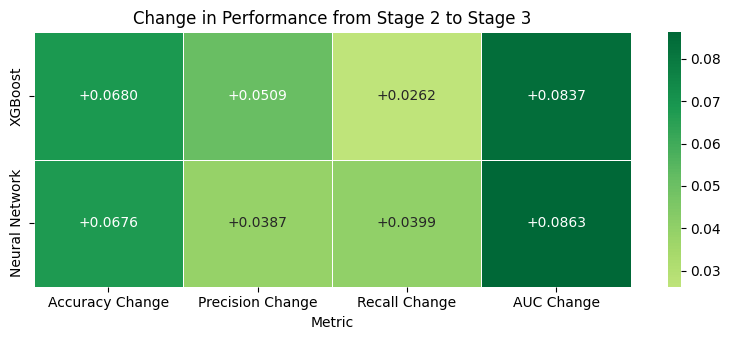

In [ ]:
plot_stage_change_heatmap(
    stage_metrics,
    from_stage='Stage 2',
    to_stage='Stage 3'
)

**Summary of baseline models (Stage 2 vs Stage 3):**

Both models improved substantially from Stage 2 to Stage 3 across all evaluation metrics.

XGBoost improved by:
- Accuracy: +0.0680
- Precision: +0.0509
- Recall: +0.0262
- AUC: +0.0837

Neural Network improved by:
- Accuracy: +0.0676
- Precision: +0.0387
- Recall: +0.0399
- AUC: +0.0863

In Stage 3, XGBoost remained the strongest overall model, achieving the highest Accuracy (**0.9735**) and AUC (**0.9929**).

**Why the results are different:**

A likely reason for the improvement is that Stage 3 introduced additional academic progress variables that were more directly related to the target outcome than the features available in earlier stages.

Exploratory analysis suggested that these newly introduced variables provided clearer separation between the two outcome classes, giving both models more informative inputs and improving predictive performance.

The feature importance results were also consistent with this pattern, as several of the newly added variables appeared among the strongest contributors to the model’s predictions.

Overall, Stage 3 performed better because it included features with stronger direct relevance to the outcome being predicted.

## XGBoost Hyperparameter Tuned (Stage 3)

In [79]:
# Define Stage 3 parameter grid
param_grid_stage3 = {
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200]
}

# Train tuned Stage 3 XGBoost
xgb_stage3_tuned = train_xgb_tuned(
    X_train=X_train_stage3,
    y_train=y_train_stage3,
    X_test=X_test_stage3,
    y_test=y_test_stage3,
    baseline_results=xgb_stage3_baseline,
    param_grid=param_grid_stage3,
    model_name="Stage 3 Tuned XGBoost"
)

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best Parameters Found: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
Stage 3 Tuned XGBoost Performance Metrics:
Accuracy:  0.9741
Precision: 0.9802
Recall:    0.9894
AUC:       0.9929

Change vs Baseline:
Accuracy Change:  +0.0006
Precision Change: +0.0002
Recall Change:    +0.0005
AUC Change:       +0.0001


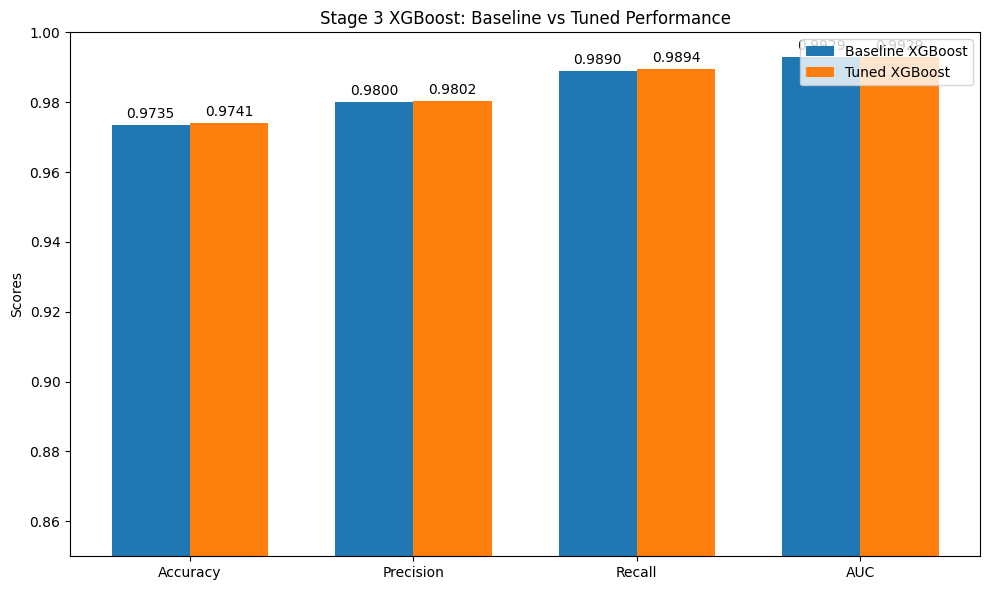

In [41]:
plot_model_comparison(
    baseline_results=xgb_stage3_baseline,
    tuned_results=xgb_stage3_tuned,
    title='Stage 3 XGBoost: Baseline vs Tuned Performance',
    baseline_label='Baseline XGBoost',
    tuned_label='Tuned XGBoost'
)

### ROC PR curves comparison

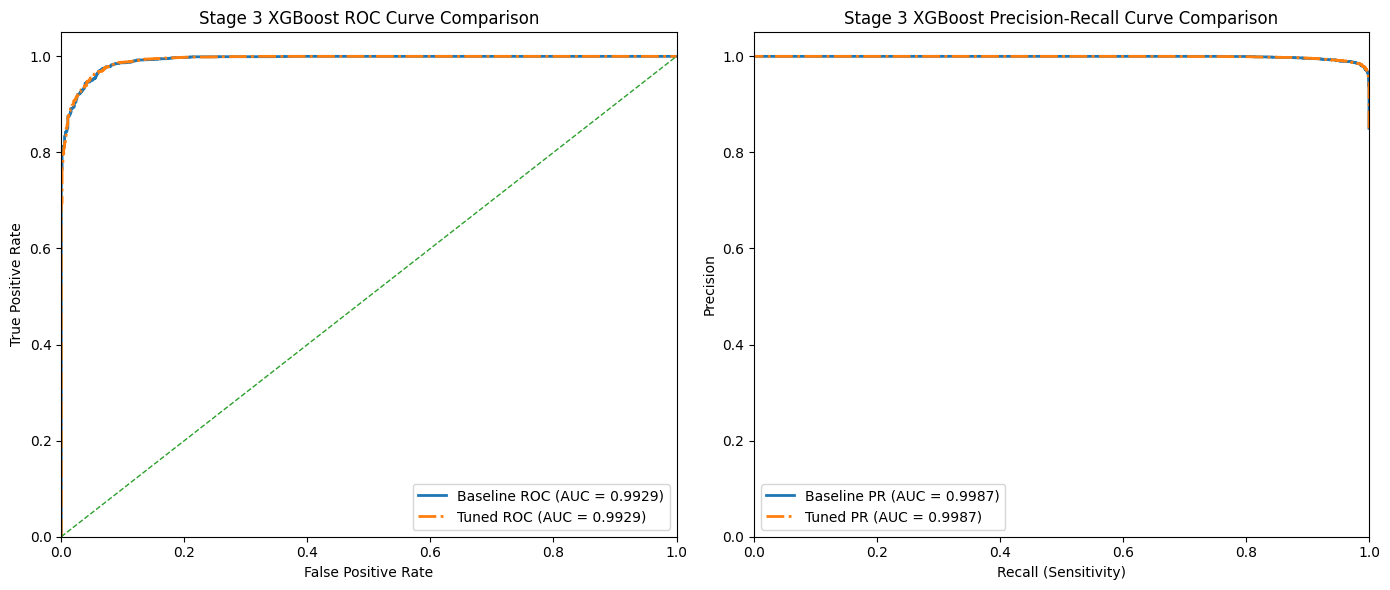

In [44]:
plot_roc_pr_comparison(
    y_true=y_test_stage3,
    y_pred_proba_baseline=xgb_stage3_baseline["y_pred_proba"],
    y_pred_proba_tuned=xgb_stage3_tuned["y_pred_proba"],
    title_prefix="Stage 3 XGBoost",
    baseline_label="Baseline",
    tuned_label="Tuned"
)

### Confusion matrix

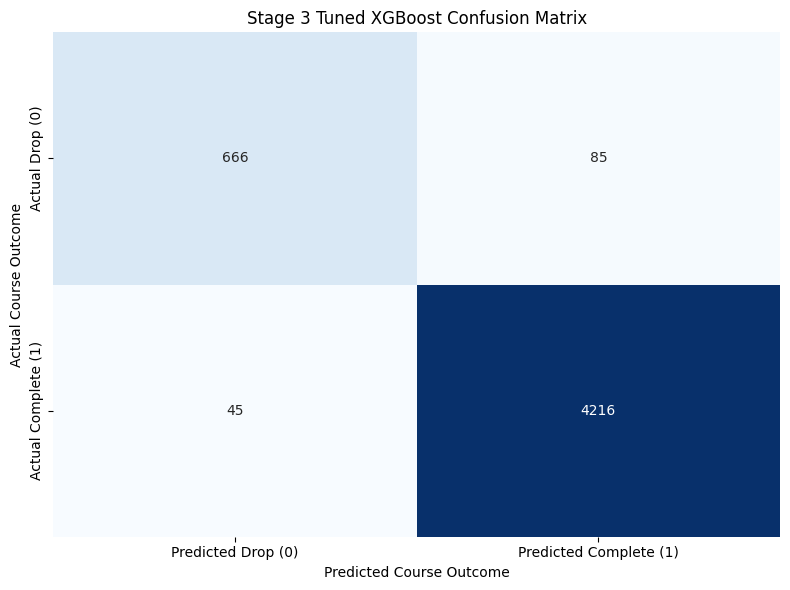

In [47]:
xgb_conf_matrix_tuned_stage3 = plot_confusion_matrix_from_preds(
    y_true=y_test_stage3,
    y_pred=xgb_stage3_tuned['y_pred'],
    title='Stage 3 Tuned XGBoost Confusion Matrix',
    figsize=(8, 6)
)

### Feature importance

In [ ]:
importance_df_stage3_tuned = plot_xgb_feature_importance(
    model=xgb_stage3_tuned['model'],
    X_train=X_train_stage3,
    stage_label='Tuned Stage 3'
)

**Summary of Stage 3 XGBoost model:**

Hyperparameter tuning was applied to the Stage 3 XGBoost model using GridSearchCV.

The best parameters found were:
- learning_rate = 0.1
- max_depth = 7
- n_estimators = 200

The tuned Stage 3 XGBoost model achieved:
- Accuracy: 0.9741
- Precision: 0.9802
- Recall: 0.9894
- AUC: 0.9929

Compared with the Stage 3 baseline, tuning produced only very small improvements:
- Accuracy: +0.0006
- Precision: +0.0002
- Recall: +0.0005
- AUC: +0.0001

These changes are extremely small, so hyperparameter tuning did not significantly improve the Stage 3 XGBoost model.

This suggests that the baseline Stage 3 XGBoost model was already performing close to optimally, and the additional Stage 3 features provided most of the performance gain rather than the tuning itself.

## Neural Network Hyperparameter Tuned (Stage 3)

In [80]:
nn_stage3_tuning = tune_nn_model(
    X_train_tf=nn_stage3_baseline['X_train_tf'],
    y_train_tf=nn_stage3_baseline['y_train_tf'],
    X_val_tf=nn_stage3_baseline['X_val_tf'],
    y_val_tf=nn_stage3_baseline['y_val_tf'],
    stage_label="Stage 3"
)

Trial 30 Complete [00h 00m 56s]
val_auc: 0.9934272170066833

Best val_auc So Far: 0.9954417943954468
Total elapsed time: 00h 08m 40s

--- BEST PARAMETERS FOUND (Stage 3) ---
Layer 1 Neurons: 128
Layer 2 Neurons: 128
Activation:      relu
Optimizer:       adam
Learning Rate:   0.001


In [82]:
nn_stage3_tuned = retrain_evaluate_tuned_nn(
    tuner=nn_stage3_tuning['tuner'],
    best_hps=nn_stage3_tuning['best_hps'],
    X_train_tf=nn_stage3_baseline['X_train_tf'],
    y_train_tf=nn_stage3_baseline['y_train_tf'],
    X_val_tf=nn_stage3_baseline['X_val_tf'],
    y_val_tf=nn_stage3_baseline['y_val_tf'],
    X_test_tf=nn_stage3_baseline['X_test_tf'],
    y_test=y_test_stage3,
    baseline_results=nn_stage3_baseline,
    model_name="Stage 3 Tuned Neural Network"
)


--- Stage 3 Tuned Neural Network Test Set Performance ---
Accuracy:  0.9721 (Baseline: 0.9703)
Precision: 0.9771 (Baseline: 0.9770)
Recall:    0.9904 (Baseline: 0.9883)
AUC:       0.9879 (Baseline: 0.9883)

Change vs Baseline:
Accuracy Change:  +0.0018
Precision Change: +0.0000
Recall Change:    +0.0021
AUC Change:       -0.0004


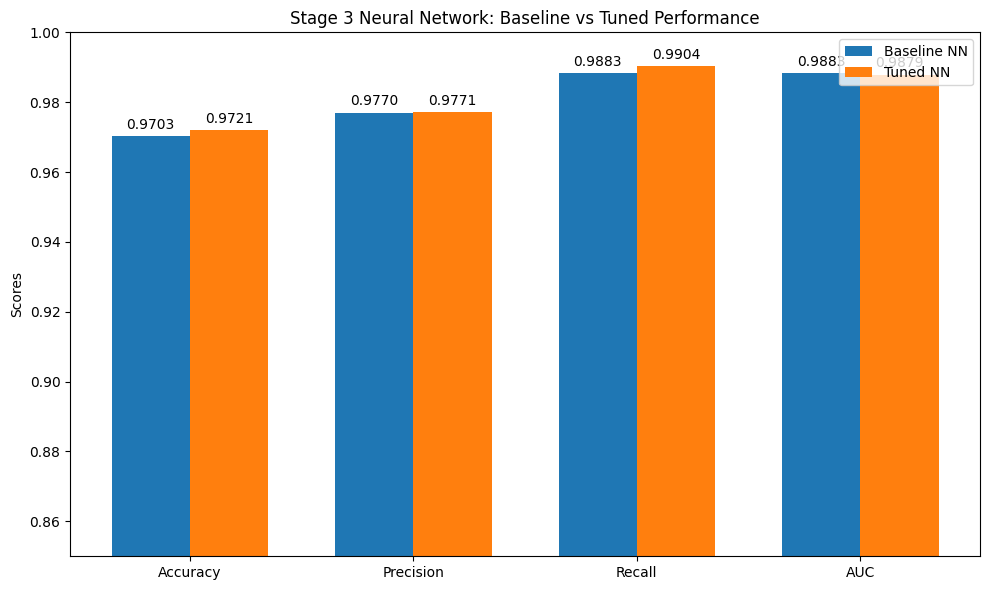

In [58]:
plot_model_comparison(
    baseline_results=nn_stage3_baseline,
    tuned_results=nn_stage3_tuned,
    title='Stage 3 Neural Network: Baseline vs Tuned Performance',
    baseline_label='Baseline NN',
    tuned_label='Tuned NN'
)

### ROC and PR Curves comparison

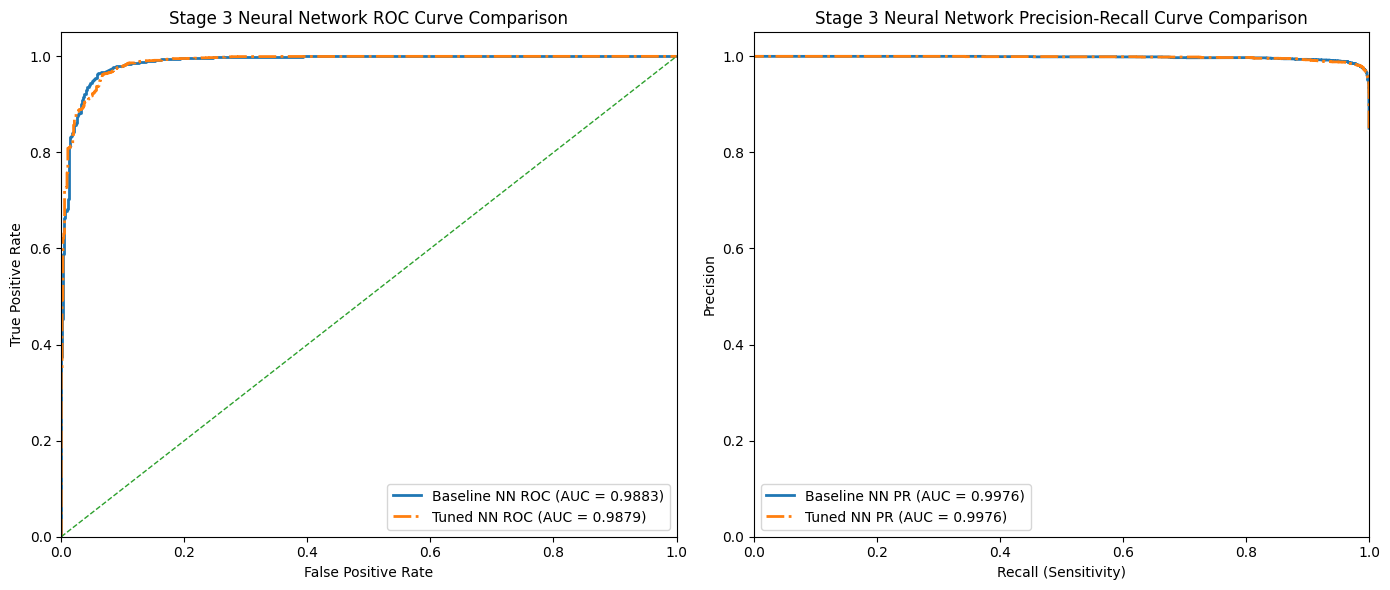

In [59]:
plot_roc_pr_comparison(
    y_true=y_test_stage3,
    y_pred_proba_baseline=nn_stage3_baseline["y_pred_proba"],
    y_pred_proba_tuned=nn_stage3_tuned["y_pred_proba"],
    title_prefix="Stage 3 Neural Network",
    baseline_label="Baseline NN",
    tuned_label="Tuned NN"
)

### Confusion Matrix

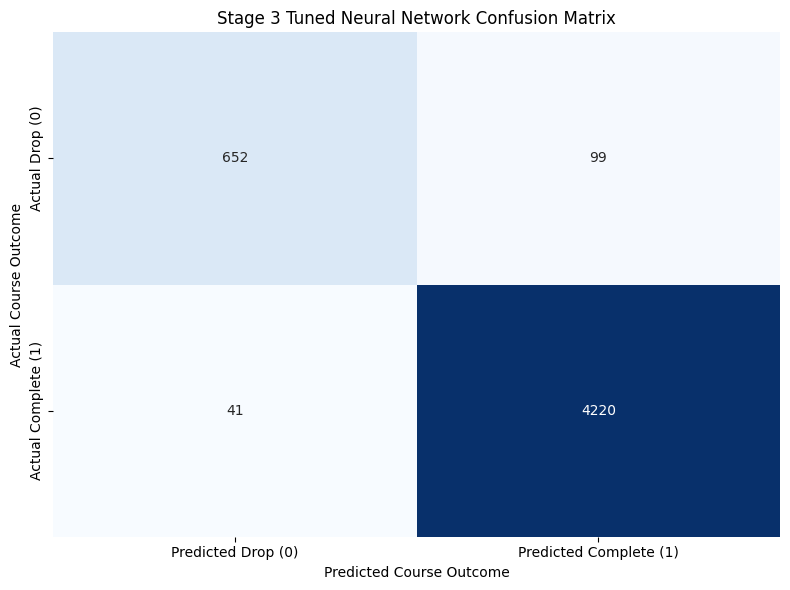

In [60]:
nn_conf_matrix_tuned_stage3 = plot_confusion_matrix_from_preds(
    y_true=y_test_stage3,
    y_pred=nn_stage3_tuned['y_pred'],
    title='Stage 3 Tuned Neural Network Confusion Matrix',
    figsize=(8, 6)
)

**Summary of NN tuned models (stage 3):**

Hyperparameter tuning was applied to the Stage 3 Neural Network model.

The tuned Stage 3 Neural Network achieved:
- Accuracy: 0.9721
- Precision: 0.9771
- Recall: 0.9904
- AUC: 0.9879

Compared with the Stage 3 baseline, tuning produced only minor changes:
- Accuracy: +0.0018
- Precision: +0.0000
- Recall: +0.0021
- AUC: -0.0004

Tuning slightly improved accuracy and recall, but AUC decreased marginally, so the overall improvement was not substantial.

Therefore, hyperparameter tuning did not significantly improve the Stage 3 Neural Network model.

Similar to XGBoost, this suggests that the Stage 3 baseline model was already very strong, and most of the performance gain came from the addition of the new academic-performance features rather than from tuning.

## Comparison of tuned results (across the stages)

In [5]:
# Add stage metrics to stage metrics dict
# Due to time limitations and the Colab runtime disconnecting, I've had to hard code the results.
# I recognise that this isn't the best solution. 
stage_metrics_tuned['Stage 3'] = {
    'XGBoost': {
        'accuracy': 0.9741,
        'precision': 0.9802,
        'recall': 0.9894,
        'auc': 0.9929 
    },
    'Neural Network': {
        'accuracy': 0.9721,
        'precision': 0.9771,
        'recall': 0.9904,
        'auc': 0.9879
    }
}

In [8]:
stage_metrics_tuned

{'Stage 1': {'XGBoost': {'accuracy': 0.8929,
   'precision': 0.9199,
   'recall': 0.9573,
   'auc': 0.8807},
  'Neural Network': {'accuracy': 0.8945,
   'precision': 0.9174,
   'recall': 0.9625,
   'auc': 0.8787}},
 'Stage 2': {'XGBoost': {'accuracy': 0.9055,
   'precision': 0.9299,
   'recall': 0.9619,
   'auc': 0.9105},
  'Neural Network': {'accuracy': 0.9039,
   'precision': 0.9319,
   'recall': 0.9574,
   'auc': 0.904}},
 'Stage 3': {'XGBoost': {'accuracy': 0.9741,
   'precision': 0.9802,
   'recall': 0.9894,
   'auc': 0.9929},
  'Neural Network': {'accuracy': 0.9721,
   'precision': 0.9771,
   'recall': 0.9904,
   'auc': 0.9879}}}

In [11]:
comparison_df_tuned = build_stage_comparison_df(stage_metrics_tuned)

print("Stage 2 vs Stage 3 Tuned Model Performance Comparison")
display(comparison_df)

Stage 2 vs Stage 3 Tuned Model Performance Comparison


,Model,Stage,Accuracy,Precision,Recall,AUC
0,XGBoost,Stage 1,0.8929,0.9199,0.9573,0.8807
1,Neural Network,Stage 1,0.8945,0.9174,0.9625,0.8787
2,XGBoost,Stage 2,0.9055,0.9299,0.9619,0.9105
3,Neural Network,Stage 2,0.9039,0.9319,0.9574,0.9040
4,XGBoost,Stage 3,0.9741,0.9802,0.9894,0.9929
5,Neural Network,Stage 3,0.9721,0.9771,0.9904,0.9879


In [12]:
change_df_2_3_tuned = build_stage_change_display_df(
    stage_metrics_tuned,
    from_stage='Stage 2',
    to_stage='Stage 3'
)

print("Change in Tuned Model Performance from Stage 2 to Stage 3")
display(change_df_2_3)

Change in Tuned Model Performance from Stage 2 to Stage 3


,Model,Accuracy Change,Precision Change,Recall Change,AUC Change
0,XGBoost,+0.0686,+0.0503,+0.0275,+0.0824
1,Neural Network,+0.0682,+0.0452,+0.0330,+0.0839


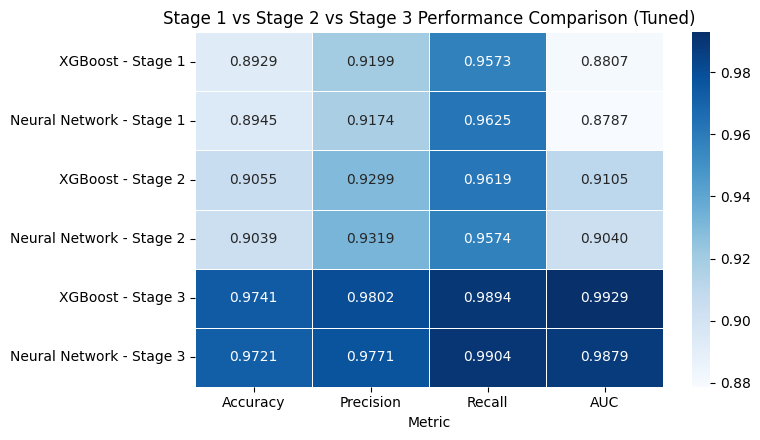

In [15]:
plot_stage_comparison_heatmap(
    comparison_df_tuned,
    title='Stage 1 vs Stage 2 vs Stage 3 Performance Comparison (Tuned)'
)

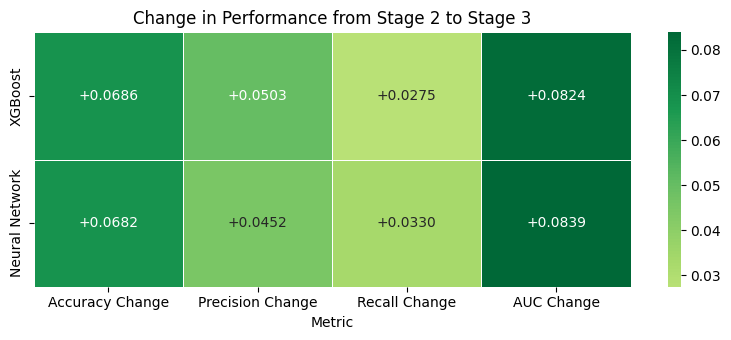

In [16]:
plot_stage_change_heatmap(
    stage_metrics_tuned,
    from_stage='Stage 2',
    to_stage='Stage 3'
)

**Summary of tuned models (Stage 2 vs Stage 3):**

Both tuned models improved substantially from Stage 2 to Stage 3 across all evaluation metrics.

Tuned XGBoost improved by:
- Accuracy: +0.0686
- Precision: +0.0503
- Recall: +0.0275
- AUC: +0.0824

Tuned Neural Network improved by:
- Accuracy: +0.0682
- Precision: +0.0452
- Recall: +0.0330
- AUC: +0.0839

In Stage 3, tuned XGBoost remained the strongest overall tuned model, achieving the highest Accuracy (**0.9741**) and AUC (**0.9929**).

**Why the results are different:**

The same overall pattern was observed for the tuned models as for the baseline models. A likely reason for the improvement is that Stage 3 introduced additional variables with stronger direct relevance to the target outcome than the features available in earlier stages.

Overall, the tuned Stage 3 models performed better because they benefited from a richer and more informative feature set. Hyperparameter tuning itself produced only marginal additional gains, while the main improvement came from the expanded Stage 3 inputs.

## Final thoughts:

In summary, the strongest results were achieved in Stage 3, with XGBoost emerging as the best overall model; the main improvement came from the addition of academic-performance features, while hyperparameter tuning offered only limited extra benefit.